# GVH — N-Body Critical Expansion Hypothesis 0.1

## Étude exploratoire d’un seuil dynamique d’expansion apparente

Ce notebook teste si un système gravitationnel à \(N\) corps peut produire
spontanément une augmentation collective et durable des distances entre les corps,
sans imposer initialement une expansion cosmologique de l’espace.

L’objectif est de distinguer :

1. le mouvement propre des corps ;
2. la dispersion gravitationnelle collective ;
3. une éventuelle relation vitesse–distance émergente ;
4. un véritable terme d’expansion cosmologique imposé par un facteur d’échelle ;
5. les transitions critiques détectées par les observables GVH.

Cette étude est exploratoire. Elle ne constitue pas une alternative démontrée
au modèle cosmologique standard.

## 1. Question scientifique

Nous testons l’hypothèse suivante :

> Existe-t-il un seuil critique dynamique au-delà duquel un système gravitationnel
> à plusieurs corps présente une augmentation collective des distances pouvant
> être confondue avec une expansion cosmologique ?

La vitesse radiale totale d’un corps peut être conceptuellement décomposée comme :

\[
v_{\mathrm{obs},i}
=
v_{\mathrm{pec},i}
+
v_{\mathrm{coll},i}
+
H(t)\,r_i,
\]

où :

- \(v_{\mathrm{pec},i}\) est la vitesse particulière du corps ;
- \(v_{\mathrm{coll},i}\) est une éventuelle composante collective émergente ;
- \(H(t)r_i\) est un terme d’expansion cosmologique explicitement imposé ;
- \(r_i\) est la distance au centre de masse du système.

Dans la première expérience, nous poserons :

\[
H(t)=0.
\]

Ainsi, toute expansion apparente devra émerger uniquement de la dynamique
gravitationnelle du système.

## 2. Hypothèses testées

### \(H_0\) — Hypothèse nulle

Le système à \(N\) corps ne produit pas d’expansion collective durable.

L’augmentation éventuelle des distances est seulement due :

- aux trajectoires individuelles ;
- aux éjections gravitationnelles ;
- aux conditions initiales ;
- aux fluctuations transitoires.

### \(H_1\) — Expansion collective émergente

Le système développe un régime dans lequel :

\[
\langle v_r \rangle > 0
\]

et où cette vitesse radiale moyenne reste positive pendant une durée significative.

### \(H_2\) — Relation de type Hubble émergente

Il existe un intervalle temporel pendant lequel :

\[
v_{r,i} \approx H_{\mathrm{eff}}(t)\,r_i.
\]

Le coefficient \(H_{\mathrm{eff}}\) serait alors une grandeur émergente du système,
et non un paramètre cosmologique imposé.

### \(H_3\) — Seuil critique GVH

La transition vers le régime expansif coïncide avec une modification significative
des observables GVH :

\[
D_T,\quad S_T,\quad R_{\mathrm{super}},\quad D_c,
\]

ou avec une nouvelle observable critique propre aux systèmes à \(N\) corps.

## 3. État mécanique du système

Pour \(N\) corps, l’état complet au temps \(t_k\) est :

\[
X_k =
\left(
\mathbf r_1,\ldots,\mathbf r_N,
\mathbf v_1,\ldots,\mathbf v_N
\right)_k.
\]

Pour chaque corps \(i\) :

\[
\mathbf r_i =
(x_i,y_i,z_i),
\]

\[
\mathbf v_i =
(v_{x,i},v_{y,i},v_{z,i}).
\]

La dimension totale de l’espace d’état est donc :

\[
\dim(X)=6N.
\]

Les masses sont regroupées dans :

\[
\mathbf m =
(m_1,\ldots,m_N).
\]

Elles sont considérées comme des paramètres physiques constants dans la
première version du modèle.

## 4. Dynamique gravitationnelle newtonienne

Pour chaque corps \(i\), l’accélération est :

\[
\frac{d^2\mathbf r_i}{dt^2}
=
G
\sum_{\substack{j=1 \\ j\neq i}}^N
m_j
\frac{\mathbf r_j-\mathbf r_i}
{\left\|\mathbf r_j-\mathbf r_i\right\|^3}.
\]

La dynamique du premier ordre devient :

\[
\frac{d\mathbf r_i}{dt}
=
\mathbf v_i,
\]

\[
\frac{d\mathbf v_i}{dt}
=
G
\sum_{\substack{j=1 \\ j\neq i}}^N
m_j
\frac{\mathbf r_j-\mathbf r_i}
{\left\|\mathbf r_j-\mathbf r_i\right\|^3}.
\]

Dans la version 0.1 :

- aucune expansion cosmologique n’est ajoutée ;
- aucune énergie noire n’est introduite ;
- aucune force répulsive supplémentaire n’est imposée ;
- les résultats proviennent uniquement des interactions gravitationnelles
  et des conditions initiales.

In [ ]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.stats import linregress

np.set_printoptions(
    precision=6,
    suppress=True
)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Configuration initialisée.")
print(f"Graine aléatoire : {RANDOM_SEED}")

In [ ]:
# ============================================================
# Paramètres fondamentaux — unités normalisées
# ============================================================

G = 1.0

N_BODIES = 20

T_START = 0.0
T_END = 50.0
N_STEPS = 5001

T_EVAL = np.linspace(
    T_START,
    T_END,
    N_STEPS
)

DT = T_EVAL[1] - T_EVAL[0]

SOFTENING = 1e-3

RTOL = 1e-10
ATOL = 1e-12

print("Paramètres numériques")
print("---------------------")
print(f"N corps       : {N_BODIES}")
print(f"Intervalle    : [{T_START}, {T_END}]")
print(f"Pas de sortie : {DT:.6f}")
print(f"Softening     : {SOFTENING}")
print(f"RTOL          : {RTOL}")
print(f"ATOL          : {ATOL}")

In [ ]:
# ============================================================
# Expérience A — Conditions initiales d'un système lié
# ============================================================

def generate_bound_initial_conditions(
    n_bodies: int,
    rng: np.random.Generator,
    total_mass: float = 1.0,
    position_scale: float = 1.0,
    velocity_scale: float = 0.20,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Génère un système gravitationnel initialement compact.

    Returns
    -------
    masses : ndarray, shape (N,)
        Masses des corps.
    positions : ndarray, shape (N, 3)
        Positions initiales.
    velocities : ndarray, shape (N, 3)
        Vitesses initiales recentrées.
    """

    if n_bodies < 2:
        raise ValueError("Le système doit contenir au moins deux corps.")

    # Masses identiques pour le contrôle initial
    masses = np.full(
        n_bodies,
        total_mass / n_bodies,
        dtype=float
    )

    # Positions aléatoires dans une distribution sphérique
    positions = rng.normal(
        loc=0.0,
        scale=position_scale,
        size=(n_bodies, 3)
    )

    # Recentrage du centre de masse
    center_of_mass = np.average(
        positions,
        axis=0,
        weights=masses
    )

    positions -= center_of_mass

    # Vitesses aléatoires modérées
    velocities = rng.normal(
        loc=0.0,
        scale=velocity_scale,
        size=(n_bodies, 3)
    )

    # Suppression de la vitesse globale du centre de masse
    center_of_mass_velocity = np.average(
        velocities,
        axis=0,
        weights=masses
    )

    velocities -= center_of_mass_velocity

    return masses, positions, velocities


masses_A, positions_A0, velocities_A0 = generate_bound_initial_conditions(
    n_bodies=N_BODIES,
    rng=rng,
    total_mass=1.0,
    position_scale=1.0,
    velocity_scale=0.20,
)

print("Conditions initiales générées.")
print(f"Forme masses     : {masses_A.shape}")
print(f"Forme positions  : {positions_A0.shape}")
print(f"Forme vitesses   : {velocities_A0.shape}")

In [ ]:
# ============================================================
# Contrôle du centre de masse
# ============================================================

center_of_mass_A = np.average(
    positions_A0,
    axis=0,
    weights=masses_A
)

center_of_mass_velocity_A = np.average(
    velocities_A0,
    axis=0,
    weights=masses_A
)

total_momentum_A = np.sum(
    masses_A[:, None] * velocities_A0,
    axis=0
)

print("Centre de masse initial :")
print(center_of_mass_A)

print("\nVitesse du centre de masse :")
print(center_of_mass_velocity_A)

print("\nQuantité de mouvement totale :")
print(total_momentum_A)

In [ ]:
# ============================================================
# Énergies mécaniques
# ============================================================

def kinetic_energy(
    masses: np.ndarray,
    velocities: np.ndarray
) -> float:
    """Calcule l'énergie cinétique totale."""

    return 0.5 * np.sum(
        masses * np.sum(velocities**2, axis=1)
    )


def potential_energy(
    masses: np.ndarray,
    positions: np.ndarray,
    G: float,
    softening: float
) -> float:
    """
    Calcule l'énergie potentielle gravitationnelle totale.
    Chaque paire est comptée une seule fois.
    """

    n_bodies = len(masses)
    energy = 0.0

    for i in range(n_bodies - 1):
        for j in range(i + 1, n_bodies):
            separation = positions[j] - positions[i]

            distance_softened = np.sqrt(
                np.dot(separation, separation)
                + softening**2
            )

            energy -= (
                G
                * masses[i]
                * masses[j]
                / distance_softened
            )

    return energy


K_A0 = kinetic_energy(
    masses_A,
    velocities_A0
)

U_A0 = potential_energy(
    masses_A,
    positions_A0,
    G=G,
    softening=SOFTENING
)

E_A0 = K_A0 + U_A0

virial_ratio_A0 = 2.0 * K_A0 / abs(U_A0)

print("Énergies initiales — Expérience A")
print("---------------------------------")
print(f"Énergie cinétique K   : {K_A0:.8f}")
print(f"Énergie potentielle U : {U_A0:.8f}")
print(f"Énergie totale E      : {E_A0:.8f}")
print(f"Rapport viriel 2K/|U| : {virial_ratio_A0:.8f}")

In [ ]:
# ============================================================
# Ajustement vers un rapport viriel cible
# ============================================================

def rescale_velocities_to_virial_ratio(
    masses: np.ndarray,
    positions: np.ndarray,
    velocities: np.ndarray,
    target_virial_ratio: float,
    G: float,
    softening: float,
) -> np.ndarray:
    """
    Redimensionne les vitesses pour imposer un rapport viriel cible :

        Q = 2K / |U|
    """

    if target_virial_ratio <= 0:
        raise ValueError(
            "Le rapport viriel cible doit être strictement positif."
        )

    K_current = kinetic_energy(
        masses,
        velocities
    )

    U_current = potential_energy(
        masses,
        positions,
        G=G,
        softening=softening
    )

    if K_current <= 0:
        raise ValueError(
            "L'énergie cinétique actuelle doit être positive."
        )

    K_target = (
        target_virial_ratio
        * abs(U_current)
        / 2.0
    )

    scale_factor = np.sqrt(
        K_target / K_current
    )

    return velocities * scale_factor


TARGET_VIRIAL_RATIO_A = 1.0

velocities_A0 = rescale_velocities_to_virial_ratio(
    masses=masses_A,
    positions=positions_A0,
    velocities=velocities_A0,
    target_virial_ratio=TARGET_VIRIAL_RATIO_A,
    G=G,
    softening=SOFTENING,
)

K_A0 = kinetic_energy(
    masses_A,
    velocities_A0
)

U_A0 = potential_energy(
    masses_A,
    positions_A0,
    G=G,
    softening=SOFTENING
)

E_A0 = K_A0 + U_A0

virial_ratio_A0 = 2.0 * K_A0 / abs(U_A0)

print("Après virialisation")
print("-------------------")
print(f"K initial          : {K_A0:.8f}")
print(f"U initial          : {U_A0:.8f}")
print(f"E initial          : {E_A0:.8f}")
print(f"Rapport viriel     : {virial_ratio_A0:.8f}")

In [ ]:
# ============================================================
# Vitesse radiale initiale
# ============================================================

def radial_velocities(
    positions: np.ndarray,
    velocities: np.ndarray,
    epsilon: float = 1e-15
) -> np.ndarray:
    """
    Calcule la vitesse radiale de chaque corps relativement
    au centre de masse placé à l'origine.
    """

    radii = np.linalg.norm(
        positions,
        axis=1
    )

    return np.sum(
        positions * velocities,
        axis=1
    ) / np.maximum(radii, epsilon)


radial_velocities_A0 = radial_velocities(
    positions_A0,
    velocities_A0
)

mean_radial_velocity_A0 = np.mean(
    radial_velocities_A0
)

median_radial_velocity_A0 = np.median(
    radial_velocities_A0
)

print("Vitesses radiales initiales")
print("---------------------------")
print(f"Moyenne : {mean_radial_velocity_A0:.8f}")
print(f"Médiane : {median_radial_velocity_A0:.8f}")
print(f"Minimum : {radial_velocities_A0.min():.8f}")
print(f"Maximum : {radial_velocities_A0.max():.8f}")

In [ ]:
# ============================================================
# Mesure du mode collectif d'expansion initial
# ============================================================

def effective_expansion_rate(
    masses: np.ndarray,
    positions: np.ndarray,
    velocities: np.ndarray,
    epsilon: float = 1e-15,
) -> float:
    """
    Estime le coefficient collectif H_eff dans :

        v_i ≈ H_eff * r_i

    au sens des moindres carrés pondérés par les masses.
    """

    numerator = np.sum(
        masses[:, None] * positions * velocities
    )

    denominator = np.sum(
        masses * np.sum(positions**2, axis=1)
    )

    if denominator <= epsilon:
        raise ValueError(
            "Le moment quadratique spatial est trop faible."
        )

    return numerator / denominator


H_eff_A0_before = effective_expansion_rate(
    masses=masses_A,
    positions=positions_A0,
    velocities=velocities_A0,
)

print("Mode collectif initial")
print("----------------------")
print(f"H_eff initial : {H_eff_A0_before:.12f}")

In [ ]:
# ============================================================
# Suppression de la composante d'expansion collective
# ============================================================

def remove_collective_expansion_mode(
    masses: np.ndarray,
    positions: np.ndarray,
    velocities: np.ndarray,
) -> tuple[np.ndarray, float]:
    """
    Retire le meilleur mode collectif :

        v_exp,i = H_eff * r_i

    sans annuler les mouvements particuliers individuels.
    """

    H_eff = effective_expansion_rate(
        masses=masses,
        positions=positions,
        velocities=velocities,
    )

    corrected_velocities = (
        velocities
        - H_eff * positions
    )

    # Correction numérique résiduelle du mouvement du centre de masse
    velocity_com = np.average(
        corrected_velocities,
        axis=0,
        weights=masses,
    )

    corrected_velocities -= velocity_com

    return corrected_velocities, H_eff


velocities_A0, removed_H_A0 = remove_collective_expansion_mode(
    masses=masses_A,
    positions=positions_A0,
    velocities=velocities_A0,
)

print("Correction appliquée")
print("--------------------")
print(f"Mode H_eff retiré : {removed_H_A0:.12f}")

In [ ]:
# ============================================================
# Nouvelle virialisation après suppression du mode collectif
# ============================================================

velocities_A0 = rescale_velocities_to_virial_ratio(
    masses=masses_A,
    positions=positions_A0,
    velocities=velocities_A0,
    target_virial_ratio=TARGET_VIRIAL_RATIO_A,
    G=G,
    softening=SOFTENING,
)

K_A0 = kinetic_energy(
    masses_A,
    velocities_A0,
)

U_A0 = potential_energy(
    masses_A,
    positions_A0,
    G=G,
    softening=SOFTENING,
)

E_A0 = K_A0 + U_A0

virial_ratio_A0 = 2.0 * K_A0 / abs(U_A0)

H_eff_A0_after = effective_expansion_rate(
    masses=masses_A,
    positions=positions_A0,
    velocities=velocities_A0,
)

radial_velocities_A0 = radial_velocities(
    positions_A0,
    velocities_A0,
)

center_of_mass_velocity_A = np.average(
    velocities_A0,
    axis=0,
    weights=masses_A,
)

print("Contrôle final — Expérience A")
print("-----------------------------")
print(f"K initial             : {K_A0:.12f}")
print(f"U initial             : {U_A0:.12f}")
print(f"E initial             : {E_A0:.12f}")
print(f"Rapport viriel        : {virial_ratio_A0:.12f}")
print(f"H_eff résiduel        : {H_eff_A0_after:.12e}")
print(f"Vitesse radiale moy.  : {radial_velocities_A0.mean():.12f}")
print(f"Vitesse radiale méd.  : {np.median(radial_velocities_A0):.12f}")
print(f"Vitesse du CM         : {center_of_mass_velocity_A}")

In [ ]:
# ============================================================
# Conversion entre matrices physiques et vecteur d'état
# ============================================================

def pack_state(
    positions: np.ndarray,
    velocities: np.ndarray,
) -> np.ndarray:
    """
    Convertit les positions et vitesses de forme (N, 3)
    en un vecteur d'état de longueur 6N.
    """

    positions = np.asarray(positions, dtype=float)
    velocities = np.asarray(velocities, dtype=float)

    if positions.ndim != 2 or positions.shape[1] != 3:
        raise ValueError(
            "positions doit avoir la forme (N, 3)."
        )

    if velocities.shape != positions.shape:
        raise ValueError(
            "velocities doit avoir la même forme que positions."
        )

    return np.concatenate([
        positions.ravel(),
        velocities.ravel(),
    ])


def unpack_state(
    state: np.ndarray,
    n_bodies: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Reconstruit les positions et vitesses de forme (N, 3)
    à partir d'un vecteur d'état de longueur 6N.
    """

    state = np.asarray(state, dtype=float)

    expected_size = 6 * n_bodies

    if state.size != expected_size:
        raise ValueError(
            f"Le vecteur doit contenir {expected_size} valeurs, "
            f"mais il en contient {state.size}."
        )

    split_index = 3 * n_bodies

    positions = state[:split_index].reshape(
        n_bodies,
        3,
    )

    velocities = state[split_index:].reshape(
        n_bodies,
        3,
    )

    return positions, velocities


state_A0 = pack_state(
    positions_A0,
    velocities_A0,
)

positions_test, velocities_test = unpack_state(
    state_A0,
    N_BODIES,
)

print("Dimension du vecteur d'état :", state_A0.shape)
print(
    "Erreur reconstruction positions :",
    np.max(np.abs(positions_test - positions_A0)),
)
print(
    "Erreur reconstruction vitesses :",
    np.max(np.abs(velocities_test - velocities_A0)),
)

In [ ]:
# ============================================================
# Accélérations gravitationnelles à N corps
# ============================================================

def gravitational_accelerations(
    positions: np.ndarray,
    masses: np.ndarray,
    G: float,
    softening: float,
) -> np.ndarray:
    """
    Calcule l'accélération gravitationnelle de chaque corps.

    Parameters
    ----------
    positions : ndarray, shape (N, 3)
        Positions des corps.
    masses : ndarray, shape (N,)
        Masses des corps.
    G : float
        Constante gravitationnelle.
    softening : float
        Paramètre de régularisation.

    Returns
    -------
    accelerations : ndarray, shape (N, 3)
        Accélérations gravitationnelles.
    """

    positions = np.asarray(positions, dtype=float)
    masses = np.asarray(masses, dtype=float)

    n_bodies = len(masses)

    if positions.shape != (n_bodies, 3):
        raise ValueError(
            "positions doit avoir la forme (N, 3)."
        )

    if np.any(masses <= 0):
        raise ValueError(
            "Toutes les masses doivent être strictement positives."
        )

    if softening < 0:
        raise ValueError(
            "Le softening doit être positif ou nul."
        )

    accelerations = np.zeros_like(
        positions,
        dtype=float,
    )

    for i in range(n_bodies):

        displacement = positions - positions[i]

        distance_squared = np.sum(
            displacement**2,
            axis=1,
        )

        softened_distance_cubed = (
            distance_squared + softening**2
        ) ** 1.5

        # Exclusion du terme j = i
        softened_distance_cubed[i] = np.inf

        weighted_displacement = (
            masses[:, None]
            * displacement
            / softened_distance_cubed[:, None]
        )

        accelerations[i] = (
            G * np.sum(
                weighted_displacement,
                axis=0,
            )
        )

    return accelerations


accelerations_A0 = gravitational_accelerations(
    positions=positions_A0,
    masses=masses_A,
    G=G,
    softening=SOFTENING,
)

print("Forme des accélérations :", accelerations_A0.shape)
print(
    "Accélération maximale initiale :",
    np.max(np.linalg.norm(accelerations_A0, axis=1)),
)

In [ ]:
# ============================================================
# Contrôle de la troisième loi de Newton
# ============================================================

total_internal_force_A0 = np.sum(
    masses_A[:, None] * accelerations_A0,
    axis=0,
)

print("Force interne totale initiale :")
print(total_internal_force_A0)

print(
    "\nNorme de la force interne totale :",
    np.linalg.norm(total_internal_force_A0),
)

In [ ]:
# ============================================================
# Système différentiel à N corps
# ============================================================

def n_body_rhs(
    time: float,
    state: np.ndarray,
    masses: np.ndarray,
    G: float,
    softening: float,
) -> np.ndarray:
    """
    Second membre du problème gravitationnel à N corps.

    d positions / dt = velocities
    d velocities / dt = accelerations
    """

    del time  # système autonome dans cette version

    n_bodies = len(masses)

    positions, velocities = unpack_state(
        state,
        n_bodies,
    )

    accelerations = gravitational_accelerations(
        positions=positions,
        masses=masses,
        G=G,
        softening=softening,
    )

    return pack_state(
        positions=velocities,
        velocities=accelerations,
    )


derivative_A0 = n_body_rhs(
    time=T_START,
    state=state_A0,
    masses=masses_A,
    G=G,
    softening=SOFTENING,
)

print("Dimension de dX/dt :", derivative_A0.shape)
print(
    "Toutes les valeurs sont finies :",
    np.all(np.isfinite(derivative_A0)),
)

In [ ]:
# ============================================================
# Intégration numérique — Expérience A
# ============================================================

solution_A = solve_ivp(
    fun=n_body_rhs,
    t_span=(T_START, T_END),
    y0=state_A0,
    t_eval=T_EVAL,
    args=(
        masses_A,
        G,
        SOFTENING,
    ),
    method="DOP853",
    rtol=RTOL,
    atol=ATOL,
)

print("Intégration terminée")
print("--------------------")
print(f"Succès             : {solution_A.success}")
print(f"Message            : {solution_A.message}")
print(f"Nombre de temps    : {solution_A.t.size}")
print(f"Forme de la solution : {solution_A.y.shape}")
print(f"Évaluations RHS    : {solution_A.nfev}")

if not solution_A.success:
    raise RuntimeError(
        "L'intégration a échoué : "
        + solution_A.message
    )

In [ ]:
# ============================================================
# Reconstruction des positions et vitesses temporelles
# ============================================================

def reconstruct_trajectory(
    solution_matrix: np.ndarray,
    n_bodies: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Reconstruit les trajectoires à partir de solution.y.

    Returns
    -------
    positions_history : ndarray, shape (N_times, N, 3)
    velocities_history : ndarray, shape (N_times, N, 3)
    """

    if solution_matrix.ndim != 2:
        raise ValueError(
            "solution_matrix doit être un tableau bidimensionnel."
        )

    expected_rows = 6 * n_bodies

    if solution_matrix.shape[0] != expected_rows:
        raise ValueError(
            f"La matrice doit avoir {expected_rows} lignes."
        )

    n_times = solution_matrix.shape[1]
    split_index = 3 * n_bodies

    positions_history = (
        solution_matrix[:split_index, :]
        .T
        .reshape(n_times, n_bodies, 3)
    )

    velocities_history = (
        solution_matrix[split_index:, :]
        .T
        .reshape(n_times, n_bodies, 3)
    )

    return positions_history, velocities_history


positions_A, velocities_A = reconstruct_trajectory(
    solution_matrix=solution_A.y,
    n_bodies=N_BODIES,
)

times_A = solution_A.t

print("Trajectoires reconstruites")
print("--------------------------")
print(f"Temps      : {times_A.shape}")
print(f"Positions  : {positions_A.shape}")
print(f"Vitesses   : {velocities_A.shape}")

print(
    "\nErreur sur la position initiale :",
    np.max(np.abs(positions_A[0] - positions_A0)),
)

print(
    "Erreur sur la vitesse initiale :",
    np.max(np.abs(velocities_A[0] - velocities_A0)),
)

In [ ]:
# ============================================================
# Centre de masse et vitesse du centre de masse
# ============================================================

def center_of_mass_history(
    positions_history: np.ndarray,
    velocities_history: np.ndarray,
    masses: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calcule la position et la vitesse du centre de masse
    à chaque instant.
    """

    total_mass = np.sum(masses)

    positions_com = np.sum(
        masses[None, :, None] * positions_history,
        axis=1,
    ) / total_mass

    velocities_com = np.sum(
        masses[None, :, None] * velocities_history,
        axis=1,
    ) / total_mass

    return positions_com, velocities_com


positions_com_A, velocities_com_A = center_of_mass_history(
    positions_history=positions_A,
    velocities_history=velocities_A,
    masses=masses_A,
)

com_position_norm_A = np.linalg.norm(
    positions_com_A,
    axis=1,
)

com_velocity_norm_A = np.linalg.norm(
    velocities_com_A,
    axis=1,
)

print("Dérive du centre de masse")
print("-------------------------")
print(
    f"Position CM maximale : "
    f"{com_position_norm_A.max():.12e}"
)
print(
    f"Vitesse CM maximale  : "
    f"{com_velocity_norm_A.max():.12e}"
)

In [ ]:
# ============================================================
# Référentiel du centre de masse
# ============================================================

positions_rel_A = (
    positions_A
    - positions_com_A[:, None, :]
)

velocities_rel_A = (
    velocities_A
    - velocities_com_A[:, None, :]
)

print("Forme positions relatives :", positions_rel_A.shape)
print("Forme vitesses relatives  :", velocities_rel_A.shape)

In [ ]:
# ============================================================
# Rayon RMS
# ============================================================

def rms_radius_history(
    positions_relative: np.ndarray,
    masses: np.ndarray,
) -> np.ndarray:
    """
    Calcule le rayon RMS pondéré par les masses.
    """

    squared_radii = np.sum(
        positions_relative**2,
        axis=2,
    )

    return np.sqrt(
        np.sum(
            masses[None, :] * squared_radii,
            axis=1,
        )
        / np.sum(masses)
    )


rms_radius_A = rms_radius_history(
    positions_relative=positions_rel_A,
    masses=masses_A,
)

print("Rayon RMS")
print("----------")
print(f"R_RMS initial : {rms_radius_A[0]:.12f}")
print(f"R_RMS final   : {rms_radius_A[-1]:.12f}")
print(f"R_RMS minimum : {rms_radius_A.min():.12f}")
print(f"R_RMS maximum : {rms_radius_A.max():.12f}")
print(
    f"Variation relative finale : "
    f"{(rms_radius_A[-1] / rms_radius_A[0] - 1.0):.6%}"
)

In [ ]:
# ============================================================
# Historique des énergies mécaniques
# ============================================================

def energy_history(
    positions_history: np.ndarray,
    velocities_history: np.ndarray,
    masses: np.ndarray,
    G: float,
    softening: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Calcule K(t), U(t) et E(t).
    """

    n_times = positions_history.shape[0]

    kinetic = np.empty(n_times)
    potential = np.empty(n_times)

    for k in range(n_times):
        kinetic[k] = kinetic_energy(
            masses=masses,
            velocities=velocities_history[k],
        )

        potential[k] = potential_energy(
            masses=masses,
            positions=positions_history[k],
            G=G,
            softening=softening,
        )

    total = kinetic + potential

    return kinetic, potential, total


kinetic_A, potential_A, total_energy_A = energy_history(
    positions_history=positions_rel_A,
    velocities_history=velocities_rel_A,
    masses=masses_A,
    G=G,
    softening=SOFTENING,
)

relative_energy_error_A = (
    total_energy_A - total_energy_A[0]
) / abs(total_energy_A[0])

print("Conservation de l'énergie")
print("-------------------------")
print(f"E initiale           : {total_energy_A[0]:.12f}")
print(f"E finale             : {total_energy_A[-1]:.12f}")
print(
    f"Erreur relative finale : "
    f"{relative_energy_error_A[-1]:.12e}"
)
print(
    f"Erreur relative max.   : "
    f"{np.max(np.abs(relative_energy_error_A)):.12e}"
)

In [ ]:
# ============================================================
# Rapport viriel temporel
# ============================================================

virial_ratio_A = (
    2.0 * kinetic_A
    / np.abs(potential_A)
)

print("Rapport viriel")
print("----------------")
print(f"Q initial : {virial_ratio_A[0]:.12f}")
print(f"Q final   : {virial_ratio_A[-1]:.12f}")
print(f"Q minimum : {virial_ratio_A.min():.12f}")
print(f"Q maximum : {virial_ratio_A.max():.12f}")
print(f"Q moyen   : {virial_ratio_A.mean():.12f}")

In [ ]:
# ============================================================
# Taux collectif d'expansion H_eff(t)
# ============================================================

def effective_expansion_history(
    positions_relative: np.ndarray,
    velocities_relative: np.ndarray,
    masses: np.ndarray,
    epsilon: float = 1e-15,
) -> np.ndarray:
    """
    Calcule H_eff à chaque instant.
    """

    numerator = np.sum(
        masses[None, :, None]
        * positions_relative
        * velocities_relative,
        axis=(1, 2),
    )

    denominator = np.sum(
        masses[None, :]
        * np.sum(positions_relative**2, axis=2),
        axis=1,
    )

    return numerator / np.maximum(
        denominator,
        epsilon,
    )


H_eff_A = effective_expansion_history(
    positions_relative=positions_rel_A,
    velocities_relative=velocities_rel_A,
    masses=masses_A,
)

print("Taux collectif H_eff")
print("---------------------")
print(f"H_eff initial : {H_eff_A[0]:.12e}")
print(f"H_eff final   : {H_eff_A[-1]:.12e}")
print(f"H_eff minimum : {H_eff_A.min():.12e}")
print(f"H_eff maximum : {H_eff_A.max():.12e}")
print(f"H_eff moyen   : {H_eff_A.mean():.12e}")
print(
    "Fraction du temps avec H_eff > 0 : "
    f"{np.mean(H_eff_A > 0):.6%}"
)# ============================================================
# Taux collectif d'expansion H_eff(t)
# ============================================================

def effective_expansion_history(
    positions_relative: np.ndarray,
    velocities_relative: np.ndarray,
    masses: np.ndarray,
    epsilon: float = 1e-15,
) -> np.ndarray:
    """
    Calcule H_eff à chaque instant.
    """

    numerator = np.sum(
        masses[None, :, None]
        * positions_relative
        * velocities_relative,
        axis=(1, 2),
    )

    denominator = np.sum(
        masses[None, :]
        * np.sum(positions_relative**2, axis=2),
        axis=1,
    )

    return numerator / np.maximum(
        denominator,
        epsilon,
    )


H_eff_A = effective_expansion_history(
    positions_relative=positions_rel_A,
    velocities_relative=velocities_rel_A,
    masses=masses_A,
)

print("Taux collectif H_eff")
print("---------------------")
print(f"H_eff initial : {H_eff_A[0]:.12e}")
print(f"H_eff final   : {H_eff_A[-1]:.12e}")
print(f"H_eff minimum : {H_eff_A.min():.12e}")
print(f"H_eff maximum : {H_eff_A.max():.12e}")
print(f"H_eff moyen   : {H_eff_A.mean():.12e}")
print(
    "Fraction du temps avec H_eff > 0 : "
    f"{np.mean(H_eff_A > 0):.6%}"
)

In [ ]:
# ============================================================
# Vérification : H_eff ≈ d ln(R_RMS) / dt
# ============================================================

d_rms_radius_dt_A = np.gradient(
    rms_radius_A,
    times_A,
)

H_from_radius_A = (
    d_rms_radius_dt_A
    / rms_radius_A
)

H_consistency_error_A = (
    H_eff_A - H_from_radius_A
)

# Les extrémités sont moins précises avec np.gradient
interior_slice = slice(1, -1)

print("Cohérence de H_eff")
print("------------------")
print(
    "Erreur absolue moyenne : "
    f"{np.mean(np.abs(H_consistency_error_A[interior_slice])):.12e}"
)
print(
    "Erreur absolue maximale : "
    f"{np.max(np.abs(H_consistency_error_A[interior_slice])):.12e}"
)

In [ ]:
# ============================================================
# Ajustement radial de type Hubble
# ============================================================

def radial_hubble_fit_history(
    positions_relative: np.ndarray,
    velocities_relative: np.ndarray,
    epsilon: float = 1e-15,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Ajuste v_r = slope * r + intercept à chaque instant.

    Returns
    -------
    slopes : ndarray
        Pente de la relation vitesse-distance.
    intercepts : ndarray
        Ordonnée à l'origine.
    r_squared : ndarray
        Coefficient de détermination.
    """

    n_times = positions_relative.shape[0]

    slopes = np.empty(n_times)
    intercepts = np.empty(n_times)
    r_squared = np.empty(n_times)

    for k in range(n_times):
        positions_k = positions_relative[k]
        velocities_k = velocities_relative[k]

        radii_k = np.linalg.norm(
            positions_k,
            axis=1,
        )

        radial_velocity_k = np.sum(
            positions_k * velocities_k,
            axis=1,
        ) / np.maximum(radii_k, epsilon)

        fit = linregress(
            radii_k,
            radial_velocity_k,
        )

        slopes[k] = fit.slope
        intercepts[k] = fit.intercept
        r_squared[k] = fit.rvalue**2

    return slopes, intercepts, r_squared


H_fit_A, H_intercept_A, H_r2_A = radial_hubble_fit_history(
    positions_relative=positions_rel_A,
    velocities_relative=velocities_rel_A,
)

print("Relation vitesse-distance")
print("-------------------------")
print(f"Pente initiale : {H_fit_A[0]:.12e}")
print(f"Pente finale   : {H_fit_A[-1]:.12e}")
print(f"R² initial     : {H_r2_A[0]:.12f}")
print(f"R² final       : {H_r2_A[-1]:.12f}")
print(f"R² maximal     : {H_r2_A.max():.12f}")

In [ ]:
# ============================================================
# Tableau des diagnostics temporels
# ============================================================

diagnostics_A = pd.DataFrame({
    "time": times_A,
    "R_rms": rms_radius_A,
    "K": kinetic_A,
    "U": potential_A,
    "E": total_energy_A,
    "energy_relative_error": relative_energy_error_A,
    "virial_ratio": virial_ratio_A,
    "H_eff": H_eff_A,
    "H_from_R_rms": H_from_radius_A,
    "H_fit": H_fit_A,
    "H_fit_intercept": H_intercept_A,
    "H_fit_R2": H_r2_A,
    "COM_position_norm": com_position_norm_A,
    "COM_velocity_norm": com_velocity_norm_A,
})

print(diagnostics_A.head())
print("\nDimensions :", diagnostics_A.shape)

In [ ]:
# ============================================================
# Évolution de la taille globale du système
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    times_A,
    rms_radius_A,
)

plt.axhline(
    rms_radius_A[0],
    linestyle="--",
    label="Rayon RMS initial",
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$R_{\mathrm{rms}}$")
plt.title("Expérience A — Évolution du rayon RMS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Évolution du taux collectif
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    times_A,
    H_eff_A,
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$H_{\mathrm{eff}}(t)$")
plt.title(
    "Expérience A — Taux collectif d’expansion ou de contraction"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Erreur relative sur l'énergie
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    times_A,
    relative_energy_error_A,
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$(E(t)-E_0)/|E_0|$")
plt.title("Expérience A — Conservation de l’énergie")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Pente et qualité de la relation de type Hubble
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    times_A,
    H_fit_A,
    label=r"Pente $H_{\mathrm{fit}}$",
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$H_{\mathrm{fit}}$")
plt.title("Expérience A — Pente vitesse–distance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    times_A,
    H_r2_A,
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$R^2$")
plt.ylim(-0.02, 1.02)
plt.title("Expérience A — Qualité de la relation vitesse–distance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Distances individuelles au centre de masse
# ============================================================

radii_A = np.linalg.norm(
    positions_rel_A,
    axis=2,
)

print("Forme des rayons individuels :", radii_A.shape)

print("\nDistance maximale")
print("-----------------")
print(f"Initiale : {radii_A[0].max():.12f}")
print(f"Finale   : {radii_A[-1].max():.12f}")
print(f"Globale  : {radii_A.max():.12f}")

In [ ]:
# ============================================================
# Rayons de masse et rayon médian
# ============================================================

def mass_fraction_radius(
    radii: np.ndarray,
    masses: np.ndarray,
    fraction: float,
) -> float:
    """
    Rayon contenant une fraction donnée de la masse totale.
    """

    if not 0.0 < fraction <= 1.0:
        raise ValueError(
            "fraction doit appartenir à l'intervalle ]0, 1]."
        )

    order = np.argsort(radii)

    sorted_radii = radii[order]
    sorted_masses = masses[order]

    cumulative_mass = np.cumsum(sorted_masses)
    target_mass = fraction * np.sum(sorted_masses)

    index = np.searchsorted(
        cumulative_mass,
        target_mass,
        side="left",
    )

    return sorted_radii[index]


radius_median_A = np.median(
    radii_A,
    axis=1,
)

radius_50_A = np.array([
    mass_fraction_radius(radii_k, masses_A, 0.50)
    for radii_k in radii_A
])

radius_80_A = np.array([
    mass_fraction_radius(radii_k, masses_A, 0.80)
    for radii_k in radii_A
])

radius_90_A = np.array([
    mass_fraction_radius(radii_k, masses_A, 0.90)
    for radii_k in radii_A
])

radius_max_A = np.max(
    radii_A,
    axis=1,
)

print("Rayons robustes — état initial et final")
print("----------------------------------------")
print(
    f"Rayon médian : "
    f"{radius_median_A[0]:.6f} -> {radius_median_A[-1]:.6f}"
)
print(
    f"Rayon 50 %   : "
    f"{radius_50_A[0]:.6f} -> {radius_50_A[-1]:.6f}"
)
print(
    f"Rayon 80 %   : "
    f"{radius_80_A[0]:.6f} -> {radius_80_A[-1]:.6f}"
)
print(
    f"Rayon 90 %   : "
    f"{radius_90_A[0]:.6f} -> {radius_90_A[-1]:.6f}"
)
print(
    f"Rayon maximal: "
    f"{radius_max_A[0]:.6f} -> {radius_max_A[-1]:.6f}"
)

In [ ]:
# ============================================================
# Comparaison des mesures de taille
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    times_A,
    rms_radius_A,
    label=r"$R_{\mathrm{rms}}$",
)

plt.plot(
    times_A,
    radius_median_A,
    label="Rayon médian",
)

plt.plot(
    times_A,
    radius_50_A,
    label=r"$R_{50}$",
)

plt.plot(
    times_A,
    radius_80_A,
    label=r"$R_{80}$",
)

plt.plot(
    times_A,
    radius_90_A,
    label=r"$R_{90}$",
)

plt.xlabel("Temps normalisé")
plt.ylabel("Rayon")
plt.title(
    "Expérience A — Taille du cœur et du halo"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Énergie spécifique individuelle
# ============================================================

def specific_energy_per_body(
    positions: np.ndarray,
    velocities: np.ndarray,
    masses: np.ndarray,
    G: float,
    softening: float,
) -> np.ndarray:
    """
    Calcule une énergie spécifique attribuée à chaque corps.

    La moitié de l'énergie potentielle de chaque paire
    est attribuée à chacun des deux corps.
    """

    n_bodies = len(masses)

    kinetic_specific = 0.5 * np.sum(
        velocities**2,
        axis=1,
    )

    potential_specific = np.zeros(
        n_bodies,
        dtype=float,
    )

    for i in range(n_bodies):
        for j in range(n_bodies):
            if i == j:
                continue

            separation = positions[j] - positions[i]

            distance = np.sqrt(
                np.dot(separation, separation)
                + softening**2
            )

            potential_specific[i] -= (
                0.5 * G * masses[j] / distance
            )

    return kinetic_specific + potential_specific


specific_energy_A = np.array([
    specific_energy_per_body(
        positions=positions_rel_A[k],
        velocities=velocities_rel_A[k],
        masses=masses_A,
        G=G,
        softening=SOFTENING,
    )
    for k in range(len(times_A))
])

print("Forme des énergies individuelles :", specific_energy_A.shape)

reconstructed_total_energy_A = np.sum(
    masses_A[None, :] * specific_energy_A,
    axis=1,
)

energy_decomposition_error_A = (
    reconstructed_total_energy_A
    - total_energy_A
)

print(
    "Erreur maximale de reconstruction de E :",
    np.max(np.abs(energy_decomposition_error_A)),
)

In [ ]:
# ============================================================
# Classification instantanée des corps sortants
# ============================================================

def radial_velocity_history(
    positions_relative: np.ndarray,
    velocities_relative: np.ndarray,
    epsilon: float = 1e-15,
) -> np.ndarray:
    """
    Vitesses radiales de tous les corps à chaque instant.
    """

    radii = np.linalg.norm(
        positions_relative,
        axis=2,
    )

    return np.sum(
        positions_relative * velocities_relative,
        axis=2,
    ) / np.maximum(radii, epsilon)


radial_velocity_A = radial_velocity_history(
    positions_relative=positions_rel_A,
    velocities_relative=velocities_rel_A,
)

positive_energy_mask_A = (
    specific_energy_A > 0.0
)

outgoing_unbound_mask_A = (
    positive_energy_mask_A
    & (radial_velocity_A > 0.0)
)

n_positive_energy_A = np.sum(
    positive_energy_mask_A,
    axis=1,
)

n_outgoing_unbound_A = np.sum(
    outgoing_unbound_mask_A,
    axis=1,
)

print("Corps candidats à l'éjection")
print("-----------------------------")
print(
    f"Énergie positive à t=0  : "
    f"{n_positive_energy_A[0]} / {N_BODIES}"
)
print(
    f"Énergie positive à t=50 : "
    f"{n_positive_energy_A[-1]} / {N_BODIES}"
)
print(
    f"Sortants non liés à t=50: "
    f"{n_outgoing_unbound_A[-1]} / {N_BODIES}"
)
print(
    f"Maximum simultané       : "
    f"{n_outgoing_unbound_A.max()} / {N_BODIES}"
)

In [ ]:
# ============================================================
# État final de chaque corps
# ============================================================

body_summary_A = pd.DataFrame({
    "body": np.arange(N_BODIES),
    "mass": masses_A,
    "radius_initial": radii_A[0],
    "radius_final": radii_A[-1],
    "radial_velocity_final": radial_velocity_A[-1],
    "specific_energy_final": specific_energy_A[-1],
    "positive_energy_final": positive_energy_mask_A[-1],
    "outgoing_unbound_final": outgoing_unbound_mask_A[-1],
})

body_summary_A = body_summary_A.sort_values(
    by="radius_final",
    ascending=False,
).reset_index(drop=True)

print(body_summary_A)

In [ ]:
# ============================================================
# Rayon RMS tronqué
# ============================================================

def trimmed_rms_radius_history(
    positions_relative: np.ndarray,
    masses: np.ndarray,
    trim_fraction: float = 0.10,
) -> np.ndarray:
    """
    Calcule le rayon RMS après exclusion d'une fraction
    des corps les plus éloignés à chaque instant.
    """

    if not 0.0 <= trim_fraction < 1.0:
        raise ValueError(
            "trim_fraction doit appartenir à [0, 1[."
        )

    n_times, n_bodies, _ = positions_relative.shape

    n_keep = max(
        2,
        int(np.floor((1.0 - trim_fraction) * n_bodies)),
    )

    result = np.empty(n_times)

    for k in range(n_times):
        radii_squared = np.sum(
            positions_relative[k]**2,
            axis=1,
        )

        keep_indices = np.argsort(
            radii_squared
        )[:n_keep]

        selected_masses = masses[keep_indices]
        selected_radii_squared = radii_squared[keep_indices]

        result[k] = np.sqrt(
            np.sum(
                selected_masses * selected_radii_squared
            )
            / np.sum(selected_masses)
        )

    return result


rms_radius_trimmed_10_A = trimmed_rms_radius_history(
    positions_relative=positions_rel_A,
    masses=masses_A,
    trim_fraction=0.10,
)

print("Rayon RMS tronqué à 10 %")
print("-------------------------")
print(
    f"Initial : {rms_radius_trimmed_10_A[0]:.12f}"
)
print(
    f"Final   : {rms_radius_trimmed_10_A[-1]:.12f}"
)
print(
    "Variation relative finale : "
    f"{(
        rms_radius_trimmed_10_A[-1]
        / rms_radius_trimmed_10_A[0]
        - 1.0
    ):.6%}"
)

In [ ]:
# ============================================================
# Influence des objets extrêmes
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    times_A,
    rms_radius_A,
    label="RMS complet",
)

plt.plot(
    times_A,
    rms_radius_trimmed_10_A,
    label="RMS sans les 10 % les plus éloignés",
)

plt.plot(
    times_A,
    radius_50_A,
    label=r"$R_{50}$",
)

plt.plot(
    times_A,
    radius_90_A,
    label=r"$R_{90}$",
)

plt.xlabel("Temps normalisé")
plt.ylabel("Rayon")
plt.title(
    "Expérience A — Expansion globale ou éjections ?"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()# ============================================================
# Influence des objets extrêmes
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    times_A,
    rms_radius_A,
    label="RMS complet",
)

plt.plot(
    times_A,
    rms_radius_trimmed_10_A,
    label="RMS sans les 10 % les plus éloignés",
)

plt.plot(
    times_A,
    radius_50_A,
    label=r"$R_{50}$",
)

plt.plot(
    times_A,
    radius_90_A,
    label=r"$R_{90}$",
)

plt.xlabel("Temps normalisé")
plt.ylabel("Rayon")
plt.title(
    "Expérience A — Expansion globale ou éjections ?"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Énergie orbitale instantanée par corps
# ============================================================

def instantaneous_orbital_energy_per_body(
    positions: np.ndarray,
    velocities: np.ndarray,
    masses: np.ndarray,
    G: float,
    softening: float,
) -> np.ndarray:
    """
    Énergie spécifique instantanée de chaque corps :

        epsilon_i = 1/2 |v_i|² + Phi_i

    avec le potentiel complet ressenti par le corps.
    """

    n_bodies = len(masses)

    kinetic_specific = 0.5 * np.sum(
        velocities**2,
        axis=1,
    )

    gravitational_potential = np.zeros(
        n_bodies,
        dtype=float,
    )

    for i in range(n_bodies):
        displacement = positions - positions[i]

        distances = np.sqrt(
            np.sum(displacement**2, axis=1)
            + softening**2
        )

        distances[i] = np.inf

        gravitational_potential[i] = (
            -G * np.sum(masses / distances)
        )

    return kinetic_specific + gravitational_potential


orbital_energy_A = np.array([
    instantaneous_orbital_energy_per_body(
        positions=positions_rel_A[k],
        velocities=velocities_rel_A[k],
        masses=masses_A,
        G=G,
        softening=SOFTENING,
    )
    for k in range(len(times_A))
])

print("Énergie orbitale instantanée")
print("-----------------------------")
print(
    "Corps avec epsilon > 0 à t=0  :",
    np.sum(orbital_energy_A[0] > 0),
)
print(
    "Corps avec epsilon > 0 à t=50 :",
    np.sum(orbital_energy_A[-1] > 0),
)

In [ ]:
# ============================================================
# Classification des éjections persistantes
# ============================================================

FINAL_WINDOW_FRACTION = 0.20
PERSISTENCE_THRESHOLD = 0.80

window_start = int(
    (1.0 - FINAL_WINDOW_FRACTION) * len(times_A)
)

times_final_window_A = times_A[window_start:]
radii_final_window_A = radii_A[window_start:]
radial_velocity_final_window_A = radial_velocity_A[window_start:]
orbital_energy_final_window_A = orbital_energy_A[window_start:]

persistent_positive_energy_A = np.mean(
    orbital_energy_final_window_A > 0.0,
    axis=0,
)

persistent_outward_motion_A = np.mean(
    radial_velocity_final_window_A > 0.0,
    axis=0,
)

radius_slopes_final_A = np.empty(N_BODIES)

for i in range(N_BODIES):
    fit_i = linregress(
        times_final_window_A,
        radii_final_window_A[:, i],
    )

    radius_slopes_final_A[i] = fit_i.slope


persistent_escaper_A = (
    (persistent_positive_energy_A >= PERSISTENCE_THRESHOLD)
    & (persistent_outward_motion_A >= PERSISTENCE_THRESHOLD)
    & (radius_slopes_final_A > 0.0)
)

persistent_escaper_summary_A = pd.DataFrame({
    "body": np.arange(N_BODIES),
    "radius_final": radii_A[-1],
    "radial_velocity_final": radial_velocity_A[-1],
    "orbital_energy_final": orbital_energy_A[-1],
    "positive_energy_fraction": persistent_positive_energy_A,
    "outward_fraction": persistent_outward_motion_A,
    "final_radius_slope": radius_slopes_final_A,
    "persistent_escaper": persistent_escaper_A,
}).sort_values(
    by="radius_final",
    ascending=False,
).reset_index(drop=True)

print(persistent_escaper_summary_A)

print(
    "\nNombre d’éjections persistantes :",
    persistent_escaper_A.sum(),
    "/",
    N_BODIES,
)

In [ ]:
# ============================================================
# Sous-système sans les éjectés persistants
# ============================================================

bound_indices_A = np.where(
    ~persistent_escaper_A
)[0]

masses_bound_A = masses_A[bound_indices_A]

positions_bound_A = positions_A[:, bound_indices_A, :]
velocities_bound_A = velocities_A[:, bound_indices_A, :]

positions_com_bound_A, velocities_com_bound_A = (
    center_of_mass_history(
        positions_history=positions_bound_A,
        velocities_history=velocities_bound_A,
        masses=masses_bound_A,
    )
)

positions_rel_bound_A = (
    positions_bound_A
    - positions_com_bound_A[:, None, :]
)

velocities_rel_bound_A = (
    velocities_bound_A
    - velocities_com_bound_A[:, None, :]
)

rms_radius_bound_A = rms_radius_history(
    positions_relative=positions_rel_bound_A,
    masses=masses_bound_A,
)

H_eff_bound_A = effective_expansion_history(
    positions_relative=positions_rel_bound_A,
    velocities_relative=velocities_rel_bound_A,
    masses=masses_bound_A,
)

H_fit_bound_A, H_intercept_bound_A, H_r2_bound_A = (
    radial_hubble_fit_history(
        positions_relative=positions_rel_bound_A,
        velocities_relative=velocities_rel_bound_A,
    )
)

print("Sous-système sans éjectés persistants")
print("--------------------------------------")
print(f"Nombre de corps conservés : {len(bound_indices_A)}")
print(
    f"R_RMS initial : {rms_radius_bound_A[0]:.12f}"
)
print(
    f"R_RMS final   : {rms_radius_bound_A[-1]:.12f}"
)
print(
    "Variation finale : "
    f"{(
        rms_radius_bound_A[-1]
        / rms_radius_bound_A[0]
        - 1.0
    ):.6%}"
)
print(
    f"H_eff moyen   : {H_eff_bound_A.mean():.12e}"
)
print(
    "Fraction H_eff > 0 : "
    f"{np.mean(H_eff_bound_A > 0):.6%}"
)
print(
    f"R² maximal    : {H_r2_bound_A.max():.12f}"
)
print(
    f"R² final      : {H_r2_bound_A[-1]:.12f}"
)# ============================================================
# Sous-système sans les éjectés persistants
# ============================================================

bound_indices_A = np.where(
    ~persistent_escaper_A
)[0]

masses_bound_A = masses_A[bound_indices_A]

positions_bound_A = positions_A[:, bound_indices_A, :]
velocities_bound_A = velocities_A[:, bound_indices_A, :]

positions_com_bound_A, velocities_com_bound_A = (
    center_of_mass_history(
        positions_history=positions_bound_A,
        velocities_history=velocities_bound_A,
        masses=masses_bound_A,
    )
)

positions_rel_bound_A = (
    positions_bound_A
    - positions_com_bound_A[:, None, :]
)

velocities_rel_bound_A = (
    velocities_bound_A
    - velocities_com_bound_A[:, None, :]
)

rms_radius_bound_A = rms_radius_history(
    positions_relative=positions_rel_bound_A,
    masses=masses_bound_A,
)

H_eff_bound_A = effective_expansion_history(
    positions_relative=positions_rel_bound_A,
    velocities_relative=velocities_rel_bound_A,
    masses=masses_bound_A,
)

H_fit_bound_A, H_intercept_bound_A, H_r2_bound_A = (
    radial_hubble_fit_history(
        positions_relative=positions_rel_bound_A,
        velocities_relative=velocities_rel_bound_A,
    )
)

print("Sous-système sans éjectés persistants")
print("--------------------------------------")
print(f"Nombre de corps conservés : {len(bound_indices_A)}")
print(
    f"R_RMS initial : {rms_radius_bound_A[0]:.12f}"
)
print(
    f"R_RMS final   : {rms_radius_bound_A[-1]:.12f}"
)
print(
    "Variation finale : "
    f"{(
        rms_radius_bound_A[-1]
        / rms_radius_bound_A[0]
        - 1.0
    ):.6%}"
)
print(
    f"H_eff moyen   : {H_eff_bound_A.mean():.12e}"
)
print(
    "Fraction H_eff > 0 : "
    f"{np.mean(H_eff_bound_A > 0):.6%}"
)
print(
    f"R² maximal    : {H_r2_bound_A.max():.12f}"
)
print(
    f"R² final      : {H_r2_bound_A[-1]:.12f}"
)

In [ ]:
# ============================================================
# Comparaison avec et sans éjectés persistants
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    times_A,
    rms_radius_A,
    label="Système complet",
)

plt.plot(
    times_A,
    rms_radius_bound_A,
    label="Sans éjectés persistants",
)

plt.plot(
    times_A,
    radius_50_A,
    label=r"$R_{50}$ complet",
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$R_{\mathrm{rms}}$")
plt.title(
    "Expérience A — Expansion du cœur ou effet des éjections"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Extension de l'expérience A jusqu'à t = 200
# ============================================================

T_EXTENDED_END = 200.0
N_EXTENDED_STEPS = 15001

T_EVAL_EXTENDED = np.linspace(
    T_END,
    T_EXTENDED_END,
    N_EXTENDED_STEPS,
)

state_A_at_50 = solution_A.y[:, -1]

solution_A_extended = solve_ivp(
    fun=n_body_rhs,
    t_span=(T_END, T_EXTENDED_END),
    y0=state_A_at_50,
    t_eval=T_EVAL_EXTENDED,
    args=(
        masses_A,
        G,
        SOFTENING,
    ),
    method="DOP853",
    rtol=RTOL,
    atol=ATOL,
)

print("Extension de l'intégration")
print("--------------------------")
print(f"Succès          : {solution_A_extended.success}")
print(f"Message         : {solution_A_extended.message}")
print(f"Nombre de temps : {solution_A_extended.t.size}")
print(f"Évaluations RHS : {solution_A_extended.nfev}")

if not solution_A_extended.success:
    raise RuntimeError(
        solution_A_extended.message
    )

Extension de l'intégration
--------------------------
Succès          : True
Message         : The solver successfully reached the end of the integration interval.
Nombre de temps : 15001
Évaluations RHS : 9804473


In [ ]:
# ============================================================
# Reconstruction de l'extension
# ============================================================

positions_A_extended, velocities_A_extended = reconstruct_trajectory(
    solution_matrix=solution_A_extended.y,
    n_bodies=N_BODIES,
)

times_A_long = np.concatenate([
    times_A,
    solution_A_extended.t[1:],
])

positions_A_long = np.concatenate([
    positions_A,
    positions_A_extended[1:],
], axis=0)

velocities_A_long = np.concatenate([
    velocities_A,
    velocities_A_extended[1:],
], axis=0)

print("Trajectoire prolongée")
print("---------------------")
print(f"Temps     : {times_A_long.shape}")
print(f"Positions : {positions_A_long.shape}")
print(f"Vitesses  : {velocities_A_long.shape}")
print(
    f"Intervalle : "
    f"[{times_A_long[0]}, {times_A_long[-1]}]"
)

Trajectoire prolongée
---------------------
Temps     : (20001,)
Positions : (20001, 20, 3)
Vitesses  : (20001, 20, 3)
Intervalle : [0.0, 200.0]


In [ ]:
# ============================================================
# Diagnostics géométriques prolongés
# ============================================================

positions_com_A_long, velocities_com_A_long = center_of_mass_history(
    positions_history=positions_A_long,
    velocities_history=velocities_A_long,
    masses=masses_A,
)

positions_rel_A_long = (
    positions_A_long
    - positions_com_A_long[:, None, :]
)

velocities_rel_A_long = (
    velocities_A_long
    - velocities_com_A_long[:, None, :]
)

rms_radius_A_long = rms_radius_history(
    positions_relative=positions_rel_A_long,
    masses=masses_A,
)

H_eff_A_long = effective_expansion_history(
    positions_relative=positions_rel_A_long,
    velocities_relative=velocities_rel_A_long,
    masses=masses_A,
)

radii_A_long = np.linalg.norm(
    positions_rel_A_long,
    axis=2,
)

radius_50_A_long = np.array([
    mass_fraction_radius(radii_k, masses_A, 0.50)
    for radii_k in radii_A_long
])

radius_80_A_long = np.array([
    mass_fraction_radius(radii_k, masses_A, 0.80)
    for radii_k in radii_A_long
])

radius_90_A_long = np.array([
    mass_fraction_radius(radii_k, masses_A, 0.90)
    for radii_k in radii_A_long
])

print("Évolution prolongée")
print("-------------------")
print(f"R_RMS initial : {rms_radius_A_long[0]:.12f}")
print(f"R_RMS final   : {rms_radius_A_long[-1]:.12f}")
print(f"R_RMS minimum : {rms_radius_A_long.min():.12f}")
print(f"R_RMS maximum : {rms_radius_A_long.max():.12f}")
print(
    f"Fraction H_eff > 0 : "
    f"{np.mean(H_eff_A_long > 0):.6%}"
)
print(f"H_eff final : {H_eff_A_long[-1]:.12e}")

Évolution prolongée
-------------------
R_RMS initial : 1.337612267009
R_RMS final   : 42.864568187491
R_RMS minimum : 1.277900781176
R_RMS maximum : 42.864568187491
Fraction H_eff > 0 : 91.380431%
H_eff final : 6.215558364226e-03


In [ ]:
# ============================================================
# Conservation de l'énergie sur t ∈ [0, 200]
# ============================================================

kinetic_A_long, potential_A_long, total_energy_A_long = energy_history(
    positions_history=positions_rel_A_long,
    velocities_history=velocities_rel_A_long,
    masses=masses_A,
    G=G,
    softening=SOFTENING,
)

relative_energy_error_A_long = (
    total_energy_A_long
    - total_energy_A_long[0]
) / abs(total_energy_A_long[0])

print("Conservation prolongée")
print("----------------------")
print(f"E initiale : {total_energy_A_long[0]:.12f}")
print(f"E finale   : {total_energy_A_long[-1]:.12f}")
print(
    "Erreur relative maximale : "
    f"{np.max(np.abs(relative_energy_error_A_long)):.12e}"
)

Conservation prolongée
----------------------
E initiale : -0.163855769698
E finale   : -0.163856555320
Erreur relative maximale : 4.794855083987e-06


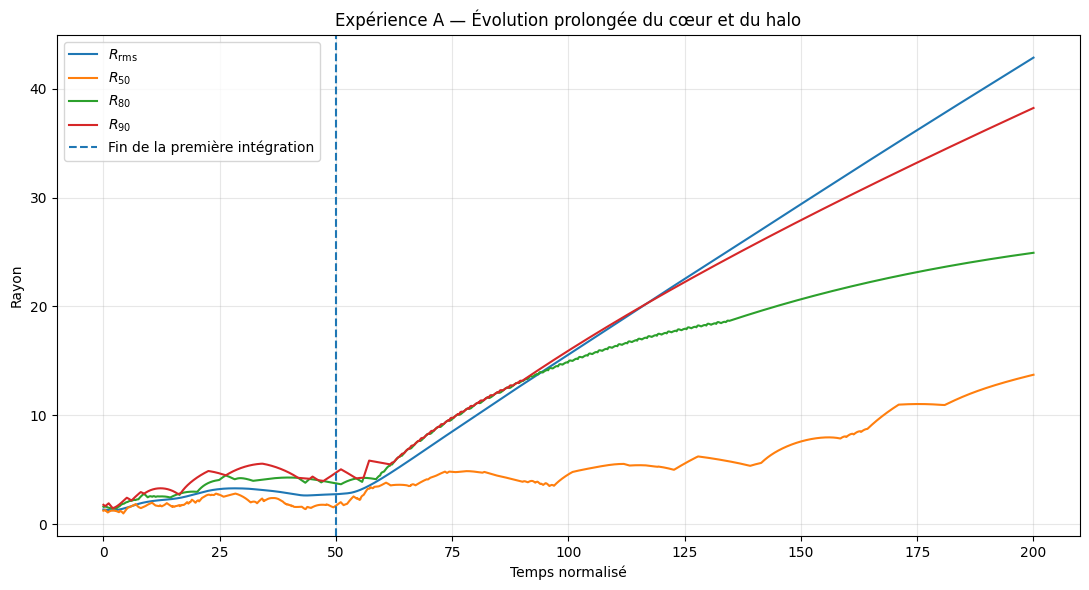

In [ ]:
# ============================================================
# Taille du système sur l'intervalle prolongé
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    times_A_long,
    rms_radius_A_long,
    label=r"$R_{\mathrm{rms}}$",
)

plt.plot(
    times_A_long,
    radius_50_A_long,
    label=r"$R_{50}$",
)

plt.plot(
    times_A_long,
    radius_80_A_long,
    label=r"$R_{80}$",
)

plt.plot(
    times_A_long,
    radius_90_A_long,
    label=r"$R_{90}$",
)

plt.axvline(
    50.0,
    linestyle="--",
    label="Fin de la première intégration",
)

plt.xlabel("Temps normalisé")
plt.ylabel("Rayon")
plt.title(
    "Expérience A — Évolution prolongée du cœur et du halo"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

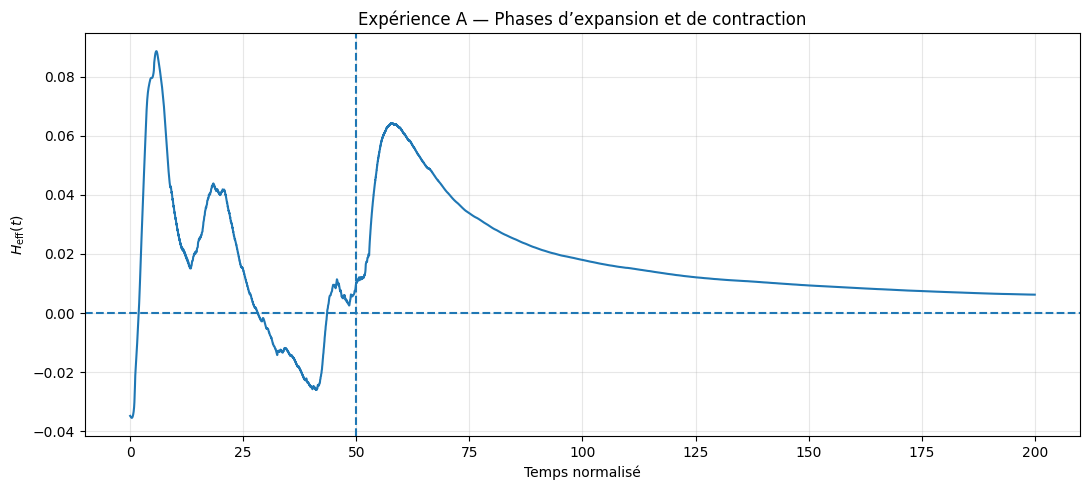

In [ ]:
# ============================================================
# Alternance du taux collectif
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    times_A_long,
    H_eff_A_long,
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.axvline(
    50.0,
    linestyle="--",
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$H_{\mathrm{eff}}(t)$")
plt.title(
    "Expérience A — Phases d’expansion et de contraction"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Exposant instantané de croissance
# alpha(t) = d ln(R_RMS) / d ln(t) = t * H_eff
# ============================================================

alpha_growth_A_long = (
    times_A_long * H_eff_A_long
)

# À t = 0, l'expression vaut formellement 0 par multiplication,
# mais elle n'a pas d'interprétation logarithmique.
alpha_growth_A_long[0] = np.nan

print("Exposant instantané de croissance")
print("---------------------------------")
print(
    f"alpha final : "
    f"{alpha_growth_A_long[-1]:.12f}"
)

late_mask_A = times_A_long >= 100.0

print(
    f"alpha moyen sur [100, 200] : "
    f"{np.nanmean(alpha_growth_A_long[late_mask_A]):.12f}"
)
print(
    f"alpha médian sur [100, 200] : "
    f"{np.nanmedian(alpha_growth_A_long[late_mask_A]):.12f}"
)

Exposant instantané de croissance
---------------------------------
alpha final : 1.243111672845
alpha moyen sur [100, 200] : 1.429684349249
alpha médian sur [100, 200] : 1.400524287103


In [ ]:
# ============================================================
# Ajustement tardif : R_RMS = A * t^p
# ============================================================

POWER_LAW_START = 100.0

power_mask_A = (
    times_A_long >= POWER_LAW_START
)

times_power_A = times_A_long[power_mask_A]
rms_power_A = rms_radius_A_long[power_mask_A]

power_fit_A = linregress(
    np.log(times_power_A),
    np.log(rms_power_A),
)

power_exponent_A = power_fit_A.slope
power_amplitude_A = np.exp(
    power_fit_A.intercept
)

power_r2_A = (
    power_fit_A.rvalue**2
)

rms_power_prediction_A = (
    power_amplitude_A
    * times_power_A**power_exponent_A
)

print("Ajustement en loi de puissance")
print("------------------------------")
print(f"Intervalle : [{POWER_LAW_START}, 200]")
print(f"A          : {power_amplitude_A:.12f}")
print(f"p          : {power_exponent_A:.12f}")
print(f"R²         : {power_r2_A:.12f}")

Ajustement en loi de puissance
------------------------------
Intervalle : [100.0, 200]
A          : 0.021561388142
p          : 1.437888268359
R²         : 0.997890388989


In [ ]:
# ============================================================
# Ajustement tardif : R_RMS = R0 * exp(H_star * t)
# ============================================================

exponential_fit_A = linregress(
    times_power_A,
    np.log(rms_power_A),
)

H_exponential_A = (
    exponential_fit_A.slope
)

R0_exponential_A = np.exp(
    exponential_fit_A.intercept
)

exponential_r2_A = (
    exponential_fit_A.rvalue**2
)

rms_exponential_prediction_A = (
    R0_exponential_A
    * np.exp(
        H_exponential_A * times_power_A
    )
)

print("Ajustement exponentiel")
print("----------------------")
print(f"R0         : {R0_exponential_A:.12f}")
print(f"H_star     : {H_exponential_A:.12e}")
print(f"R²         : {exponential_r2_A:.12f}")

Ajustement exponentiel
----------------------
R0         : 6.519453823083
H_star     : 9.770138999104e-03
R²         : 0.982060177762


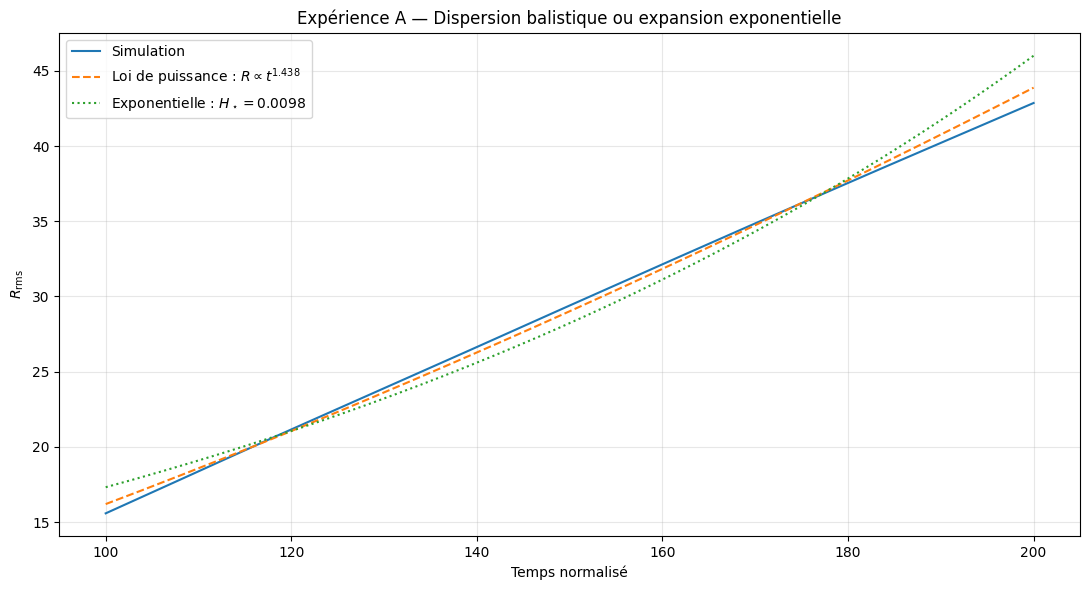

In [ ]:
# ============================================================
# Comparaison visuelle des modèles tardifs
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    times_power_A,
    rms_power_A,
    label="Simulation",
)

plt.plot(
    times_power_A,
    rms_power_prediction_A,
    linestyle="--",
    label=(
        rf"Loi de puissance : "
        rf"$R \propto t^{{{power_exponent_A:.3f}}}$"
    ),
)

plt.plot(
    times_power_A,
    rms_exponential_prediction_A,
    linestyle=":",
    label=(
        rf"Exponentielle : "
        rf"$H_\star={H_exponential_A:.4f}$"
    ),
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$R_{\mathrm{rms}}$")
plt.title(
    "Expérience A — Dispersion balistique ou expansion exponentielle"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Relation vitesse-distance jusqu'à t = 200
# ============================================================

H_fit_A_long, H_intercept_A_long, H_r2_A_long = (
    radial_hubble_fit_history(
        positions_relative=positions_rel_A_long,
        velocities_relative=velocities_rel_A_long,
    )
)

print("Relation vitesse-distance prolongée")
print("------------------------------------")
print(f"Pente finale : {H_fit_A_long[-1]:.12e}")
print(f"R² final     : {H_r2_A_long[-1]:.12f}")
print(f"R² maximal   : {H_r2_A_long.max():.12f}")

print(
    "R² moyen sur [100, 200] : "
    f"{H_r2_A_long[late_mask_A].mean():.12f}"
)

print(
    "Fraction tardive avec pente > 0 et R² > 0.8 : "
    f"{np.mean(
        (H_fit_A_long[late_mask_A] > 0.0)
        & (H_r2_A_long[late_mask_A] > 0.80)
    ):.6%}"
)

Relation vitesse-distance prolongée
------------------------------------
Pente finale : 6.552180516363e-03
R² final     : 0.535780018593
R² maximal   : 0.852075547403
R² moyen sur [100, 200] : 0.448109676199
Fraction tardive avec pente > 0 et R² > 0.8 : 0.000000%


In [ ]:
# ============================================================
# Relation vitesse-distance jusqu'à t = 200
# ============================================================

H_fit_A_long, H_intercept_A_long, H_r2_A_long = (
    radial_hubble_fit_history(
        positions_relative=positions_rel_A_long,
        velocities_relative=velocities_rel_A_long,
    )
)

print("Relation vitesse-distance prolongée")
print("------------------------------------")
print(f"Pente finale : {H_fit_A_long[-1]:.12e}")
print(f"R² final     : {H_r2_A_long[-1]:.12f}")
print(f"R² maximal   : {H_r2_A_long.max():.12f}")

print(
    "R² moyen sur [100, 200] : "
    f"{H_r2_A_long[late_mask_A].mean():.12f}"
)

print(
    "Fraction tardive avec pente > 0 et R² > 0.8 : "
    f"{np.mean(
        (H_fit_A_long[late_mask_A] > 0.0)
        & (H_r2_A_long[late_mask_A] > 0.80)
    ):.6%}"
)

Relation vitesse-distance prolongée
------------------------------------
Pente finale : 6.552180516363e-03
R² final     : 0.535780018593
R² maximal   : 0.852075547403
R² moyen sur [100, 200] : 0.448109676199
Fraction tardive avec pente > 0 et R² > 0.8 : 0.000000%


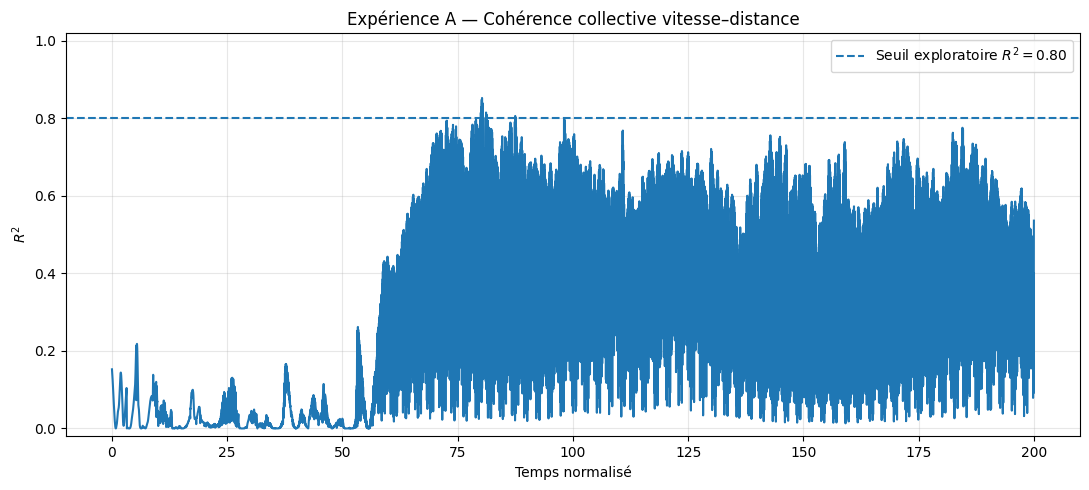

In [ ]:
# ============================================================
# Qualité de la loi vitesse-distance prolongée
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    times_A_long,
    H_r2_A_long,
)

plt.axhline(
    0.80,
    linestyle="--",
    label=r"Seuil exploratoire $R^2=0.80$",
)

plt.xlabel("Temps normalisé")
plt.ylabel(r"$R^2$")
plt.ylim(-0.02, 1.02)
plt.title(
    "Expérience A — Cohérence collective vitesse–distance"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Énergies orbitales sur la trajectoire prolongée
# ============================================================

orbital_energy_A_long = np.array([
    instantaneous_orbital_energy_per_body(
        positions=positions_rel_A_long[k],
        velocities=velocities_rel_A_long[k],
        masses=masses_A,
        G=G,
        softening=SOFTENING,
    )
    for k in range(len(times_A_long))
])

radial_velocity_A_long = radial_velocity_history(
    positions_relative=positions_rel_A_long,
    velocities_relative=velocities_rel_A_long,
)

n_positive_orbital_A_long = np.sum(
    orbital_energy_A_long > 0.0,
    axis=1,
)

n_outgoing_positive_A_long = np.sum(
    (orbital_energy_A_long > 0.0)
    & (radial_velocity_A_long > 0.0),
    axis=1,
)

print("État orbital prolongé")
print("----------------------")
print(
    f"Corps avec epsilon > 0 à t=200 : "
    f"{n_positive_orbital_A_long[-1]} / {N_BODIES}"
)
print(
    f"Sortants avec epsilon > 0      : "
    f"{n_outgoing_positive_A_long[-1]} / {N_BODIES}"
)
print(
    f"Maximum simultané non lié      : "
    f"{n_positive_orbital_A_long.max()} / {N_BODIES}"
)

État orbital prolongé
----------------------
Corps avec epsilon > 0 à t=200 : 2 / 20
Sortants avec epsilon > 0      : 2 / 20
Maximum simultané non lié      : 2 / 20


In [ ]:
# ============================================================
# Tableau final à t = 200
# ============================================================

radii_A_long = np.linalg.norm(
    positions_rel_A_long,
    axis=2,
)

body_summary_A_200 = pd.DataFrame({
    "body": np.arange(N_BODIES),
    "radius_t200": radii_A_long[-1],
    "radial_velocity_t200": radial_velocity_A_long[-1],
    "orbital_energy_t200": orbital_energy_A_long[-1],
    "positive_energy_t200": orbital_energy_A_long[-1] > 0.0,
    "outgoing_t200": radial_velocity_A_long[-1] > 0.0,
})

body_summary_A_200 = body_summary_A_200.sort_values(
    by="radius_t200",
    ascending=False,
).reset_index(drop=True)

print(body_summary_A_200)

    body  radius_t200  radial_velocity_t200  orbital_energy_t200  \
0      2   173.990097              1.167003             0.675777   
1     15    44.013091              0.206929            -0.000986   
2      1    38.237804              0.196129             0.000943   
3     19    24.930656              0.058361            -0.028193   
4      8    15.525548              0.014959            -0.155607   
5      7    15.251021              0.106247            -0.670920   
6     16    15.125730              0.031155            -0.097326   
7      6    15.083970             -0.374519            -3.229751   
8     13    15.072193             -0.498981            -3.325142   
9     18    13.724165              0.103549            -0.042422   
10     9    11.800930              0.505801            -0.275196   
11    11    11.681089              0.042246            -0.515513   
12     5    11.127417              0.035803            -0.047655   
13     4    10.724761              0.172600     

In [ ]:
# ============================================================
# Éjections persistantes sur la fenêtre t ∈ [180, 200]
# ============================================================

ESCAPER_WINDOW_START = 180.0
ESCAPER_PERSISTENCE = 0.80

escaper_window_mask_A = (
    times_A_long >= ESCAPER_WINDOW_START
)

positive_energy_fraction_200_A = np.mean(
    orbital_energy_A_long[escaper_window_mask_A] > 0.0,
    axis=0,
)

outward_fraction_200_A = np.mean(
    radial_velocity_A_long[escaper_window_mask_A] > 0.0,
    axis=0,
)

radius_slope_200_A = np.empty(N_BODIES)

for body in range(N_BODIES):
    fit_body = linregress(
        times_A_long[escaper_window_mask_A],
        radii_A_long[escaper_window_mask_A, body],
    )

    radius_slope_200_A[body] = fit_body.slope


persistent_escaper_200_A = (
    (positive_energy_fraction_200_A >= ESCAPER_PERSISTENCE)
    & (outward_fraction_200_A >= ESCAPER_PERSISTENCE)
    & (radius_slope_200_A > 0.0)
)

escaper_audit_200_A = pd.DataFrame({
    "body": np.arange(N_BODIES),
    "radius_t200": radii_A_long[-1],
    "orbital_energy_t200": orbital_energy_A_long[-1],
    "positive_energy_fraction": positive_energy_fraction_200_A,
    "outward_fraction": outward_fraction_200_A,
    "radius_slope_180_200": radius_slope_200_A,
    "persistent_escaper": persistent_escaper_200_A,
}).sort_values(
    "radius_t200",
    ascending=False,
).reset_index(drop=True)

print(escaper_audit_200_A)

print(
    "\nNombre d’éjectés persistants :",
    persistent_escaper_200_A.sum(),
    "/",
    N_BODIES,
)

    body  radius_t200  orbital_energy_t200  positive_energy_fraction  \
0      2   173.990097             0.675777                       1.0   
1     15    44.013091            -0.000986                       0.0   
2      1    38.237804             0.000943                       1.0   
3     19    24.930656            -0.028193                       0.0   
4      8    15.525548            -0.155607                       0.0   
5      7    15.251021            -0.670920                       0.0   
6     16    15.125730            -0.097326                       0.0   
7      6    15.083970            -3.229751                       0.0   
8     13    15.072193            -3.325142                       0.0   
9     18    13.724165            -0.042422                       0.0   
10     9    11.800930            -0.275196                       0.0   
11    11    11.681089            -0.515513                       0.0   
12     5    11.127417            -0.047655                      

In [ ]:
# ============================================================
# Sous-système lié après exclusion des éjectés persistants
# ============================================================

bound_indices_A_200 = np.where(
    ~persistent_escaper_200_A
)[0]

escaper_indices_A_200 = np.where(
    persistent_escaper_200_A
)[0]

masses_bound_A_200 = masses_A[
    bound_indices_A_200
]

positions_bound_A_200 = positions_A_long[
    :,
    bound_indices_A_200,
    :
]

velocities_bound_A_200 = velocities_A_long[
    :,
    bound_indices_A_200,
    :
]

positions_com_bound_A_200, velocities_com_bound_A_200 = (
    center_of_mass_history(
        positions_history=positions_bound_A_200,
        velocities_history=velocities_bound_A_200,
        masses=masses_bound_A_200,
    )
)

positions_rel_bound_A_200 = (
    positions_bound_A_200
    - positions_com_bound_A_200[:, None, :]
)

velocities_rel_bound_A_200 = (
    velocities_bound_A_200
    - velocities_com_bound_A_200[:, None, :]
)

print("Indices liés    :", bound_indices_A_200)
print("Indices éjectés :", escaper_indices_A_200)
print("Nombre lié      :", len(bound_indices_A_200))

Indices liés    : [ 0  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Indices éjectés : [1 2]
Nombre lié      : 18


In [ ]:
# ============================================================
# Taille du sous-système lié
# ============================================================

rms_radius_bound_A_200 = rms_radius_history(
    positions_relative=positions_rel_bound_A_200,
    masses=masses_bound_A_200,
)

radii_bound_A_200 = np.linalg.norm(
    positions_rel_bound_A_200,
    axis=2,
)

radius_50_bound_A_200 = np.array([
    mass_fraction_radius(
        radii_k,
        masses_bound_A_200,
        0.50,
    )
    for radii_k in radii_bound_A_200
])

radius_80_bound_A_200 = np.array([
    mass_fraction_radius(
        radii_k,
        masses_bound_A_200,
        0.80,
    )
    for radii_k in radii_bound_A_200
])

radius_90_bound_A_200 = np.array([
    mass_fraction_radius(
        radii_k,
        masses_bound_A_200,
        0.90,
    )
    for radii_k in radii_bound_A_200
])

print("Sous-système lié")
print("-----------------")
print(f"R_RMS initial : {rms_radius_bound_A_200[0]:.12f}")
print(f"R_RMS final   : {rms_radius_bound_A_200[-1]:.12f}")
print(
    "Variation finale : "
    f"{(
        rms_radius_bound_A_200[-1]
        / rms_radius_bound_A_200[0]
        - 1.0
    ):.6%}"
)
print(
    f"R50 final : {radius_50_bound_A_200[-1]:.12f}"
)
print(
    f"R80 final : {radius_80_bound_A_200[-1]:.12f}"
)
print(
    f"R90 final : {radius_90_bound_A_200[-1]:.12f}"
)

Sous-système lié
-----------------
R_RMS initial : 1.275100060811
R_RMS final   : 12.701750208198
Variation finale : 896.137527%
R50 final : 4.479063329213
R80 final : 15.334142021225
R90 final : 28.431906334561


In [ ]:
# ============================================================
# H_eff et relation vitesse-distance du sous-système lié
# ============================================================

H_eff_bound_A_200 = effective_expansion_history(
    positions_relative=positions_rel_bound_A_200,
    velocities_relative=velocities_rel_bound_A_200,
    masses=masses_bound_A_200,
)

H_fit_bound_A_200, H_intercept_bound_A_200, H_r2_bound_A_200 = (
    radial_hubble_fit_history(
        positions_relative=positions_rel_bound_A_200,
        velocities_relative=velocities_rel_bound_A_200,
    )
)

late_bound_mask_A = (
    times_A_long >= 100.0
)

print("Dynamique des corps liés")
print("-------------------------")
print(
    f"H_eff final : "
    f"{H_eff_bound_A_200[-1]:.12e}"
)
print(
    "Fraction H_eff > 0 sur [100, 200] : "
    f"{np.mean(
        H_eff_bound_A_200[late_bound_mask_A] > 0.0
    ):.6%}"
)
print(
    f"R² final : "
    f"{H_r2_bound_A_200[-1]:.12f}"
)
print(
    "R² moyen sur [100, 200] : "
    f"{np.mean(
        H_r2_bound_A_200[late_bound_mask_A]
    ):.12f}"
)
print(
    f"R² maximal : "
    f"{H_r2_bound_A_200.max():.12f}"
)

Dynamique des corps liés
-------------------------
H_eff final : 1.478093482236e-03
Fraction H_eff > 0 sur [100, 200] : 100.000000%
R² final : 0.044204029346
R² moyen sur [100, 200] : 0.062243168140
R² maximal : 0.354890536869


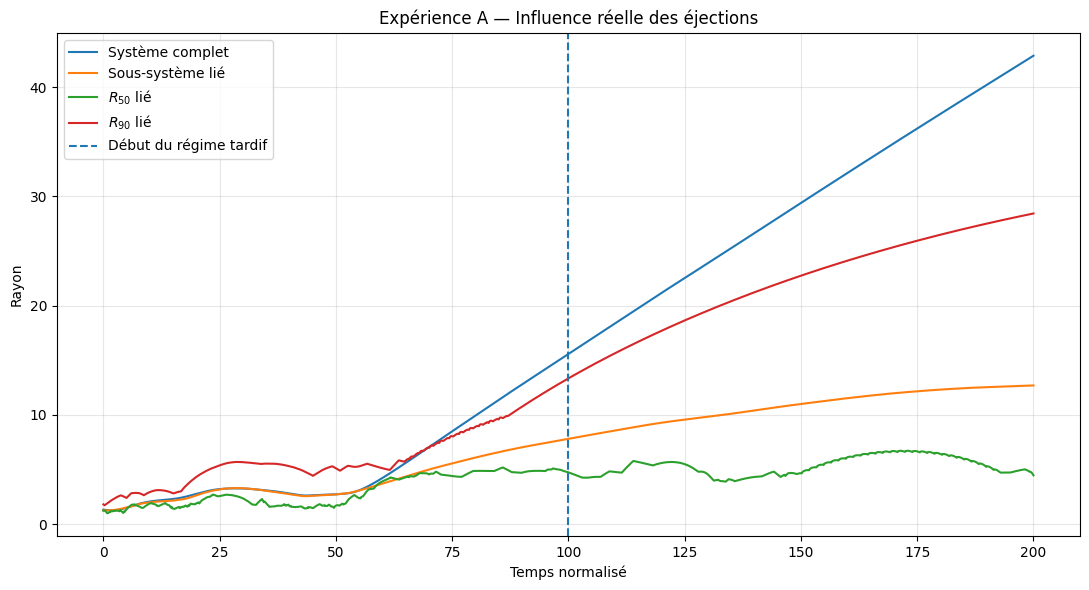

In [ ]:
# ============================================================
# Système complet contre sous-système lié
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    times_A_long,
    rms_radius_A_long,
    label="Système complet",
)

plt.plot(
    times_A_long,
    rms_radius_bound_A_200,
    label="Sous-système lié",
)

plt.plot(
    times_A_long,
    radius_50_bound_A_200,
    label=r"$R_{50}$ lié",
)

plt.plot(
    times_A_long,
    radius_90_bound_A_200,
    label=r"$R_{90}$ lié",
)

plt.axvline(
    100.0,
    linestyle="--",
    label="Début du régime tardif",
)

plt.xlabel("Temps normalisé")
plt.ylabel("Rayon")
plt.title(
    "Expérience A — Influence réelle des éjections"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Énergie mécanique propre du groupe des 16 corps retenus
# ============================================================

kinetic_bound_A_200, potential_bound_A_200, total_bound_A_200 = (
    energy_history(
        positions_history=positions_rel_bound_A_200,
        velocities_history=velocities_rel_bound_A_200,
        masses=masses_bound_A_200,
        G=G,
        softening=SOFTENING,
    )
)

virial_bound_A_200 = (
    2.0 * kinetic_bound_A_200
    / np.abs(potential_bound_A_200)
)

print("Énergie propre du groupe retenu")
print("--------------------------------")
print(f"K initial : {kinetic_bound_A_200[0]:.12f}")
print(f"U initial : {potential_bound_A_200[0]:.12f}")
print(f"E initial : {total_bound_A_200[0]:.12f}")
print()
print(f"K final   : {kinetic_bound_A_200[-1]:.12f}")
print(f"U final   : {potential_bound_A_200[-1]:.12f}")
print(f"E final   : {total_bound_A_200[-1]:.12f}")
print()
print(f"Q final   : {virial_bound_A_200[-1]:.12f}")

Énergie propre du groupe retenu
--------------------------------
K initial : 0.147181065667
U initial : -0.269395032055
E initial : -0.122213966387

K final   : 0.092979473013
U final   : -0.292874823206
E final   : -0.199895350193

Q final   : 0.634943434162


In [ ]:
# ============================================================
# Énergies orbitales relatives au seul groupe retenu
# ============================================================

orbital_energy_bound_A_200 = np.array([
    instantaneous_orbital_energy_per_body(
        positions=positions_rel_bound_A_200[k],
        velocities=velocities_rel_bound_A_200[k],
        masses=masses_bound_A_200,
        G=G,
        softening=SOFTENING,
    )
    for k in range(len(times_A_long))
])

radial_velocity_bound_A_200 = radial_velocity_history(
    positions_relative=positions_rel_bound_A_200,
    velocities_relative=velocities_rel_bound_A_200,
)

print("État orbital interne des 16 corps")
print("----------------------------------")
print(
    "Énergies positives à t=200 :",
    np.sum(orbital_energy_bound_A_200[-1] > 0.0),
    "/",
    len(bound_indices_A_200),
)

print(
    "Énergies positives et sortants :",
    np.sum(
        (orbital_energy_bound_A_200[-1] > 0.0)
        & (radial_velocity_bound_A_200[-1] > 0.0)
    ),
    "/",
    len(bound_indices_A_200),
)

In [ ]:
# ============================================================
# Tableau des 16 corps dans leur propre potentiel
# ============================================================

internal_bound_summary_A_200 = pd.DataFrame({
    "body_original": bound_indices_A_200,
    "radius_t200": radii_bound_A_200[-1],
    "radial_velocity_t200": radial_velocity_bound_A_200[-1],
    "orbital_energy_internal_t200": orbital_energy_bound_A_200[-1],
    "internally_unbound_t200": orbital_energy_bound_A_200[-1] > 0.0,
    "outgoing_t200": radial_velocity_bound_A_200[-1] > 0.0,
})

internal_bound_summary_A_200 = (
    internal_bound_summary_A_200
    .sort_values(
        "radius_t200",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(internal_bound_summary_A_200)

    body_original  radius_t200  radial_velocity_t200  \
0              15    36.609211              0.150641   
1              19    28.431906              0.087194   
2              18    18.417307              0.102163   
3               5    15.334142              0.062525   
4              16     5.431337             -0.174757   
5              17     5.136082              0.044148   
6               8     4.863573             -0.022634   
7               7     4.636602              0.149945   
8               6     4.479063             -0.529761   
9              13     4.466262             -0.558461   
10              0     3.197896             -0.305185   
11             12     2.676948             -0.408514   
12              4     2.452450             -0.421207   
13             14     2.072058              0.110954   
14              9     1.813165              0.790175   
15              3     1.810762              0.313689   
16             11     1.765900             -0.38

In [ ]:
# ============================================================
# Tableau des 16 corps dans leur propre potentiel
# ============================================================

internal_bound_summary_A_200 = pd.DataFrame({
    "body_original": bound_indices_A_200,
    "radius_t200": radii_bound_A_200[-1],
    "radial_velocity_t200": radial_velocity_bound_A_200[-1],
    "orbital_energy_internal_t200": orbital_energy_bound_A_200[-1],
    "internally_unbound_t200": orbital_energy_bound_A_200[-1] > 0.0,
    "outgoing_t200": radial_velocity_bound_A_200[-1] > 0.0,
})

internal_bound_summary_A_200 = (
    internal_bound_summary_A_200
    .sort_values(
        "radius_t200",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(internal_bound_summary_A_200)

    body_original  radius_t200  radial_velocity_t200  \
0              15    36.609211              0.150641   
1              19    28.431906              0.087194   
2              18    18.417307              0.102163   
3               5    15.334142              0.062525   
4              16     5.431337             -0.174757   
5              17     5.136082              0.044148   
6               8     4.863573             -0.022634   
7               7     4.636602              0.149945   
8               6     4.479063             -0.529761   
9              13     4.466262             -0.558461   
10              0     3.197896             -0.305185   
11             12     2.676948             -0.408514   
12              4     2.452450             -0.421207   
13             14     2.072058              0.110954   
14              9     1.813165              0.790175   
15              3     1.810762              0.313689   
16             11     1.765900             -0.38

In [ ]:
# ============================================================
# Fraction radiale sortante du groupe retenu
# ============================================================

fraction_outgoing_bound_A_200 = np.mean(
    radial_velocity_bound_A_200 > 0.0,
    axis=1,
)

mean_radial_velocity_bound_A_200 = np.mean(
    radial_velocity_bound_A_200,
    axis=1,
)

median_radial_velocity_bound_A_200 = np.median(
    radial_velocity_bound_A_200,
    axis=1,
)

print("Flux radial du groupe retenu")
print("-----------------------------")
print(
    f"Fraction sortante à t=200 : "
    f"{fraction_outgoing_bound_A_200[-1]:.6%}"
)
print(
    f"Vitesse radiale moyenne   : "
    f"{mean_radial_velocity_bound_A_200[-1]:.12f}"
)
print(
    f"Vitesse radiale médiane   : "
    f"{median_radial_velocity_bound_A_200[-1]:.12f}"
)

Flux radial du groupe retenu
-----------------------------
Fraction sortante à t=200 : 55.555556%
Vitesse radiale moyenne   : -0.054753269153
Vitesse radiale médiane   : 0.025155110165


In [ ]:
# ============================================================
# Séparations et paire la plus rapprochée
# ============================================================

def pairwise_separation_matrix(
    positions: np.ndarray,
) -> np.ndarray:
    """
    Matrice des distances entre toutes les paires.
    La diagonale est fixée à l'infini.
    """

    displacement = (
        positions[:, None, :]
        - positions[None, :, :]
    )

    distances = np.linalg.norm(
        displacement,
        axis=2,
    )

    np.fill_diagonal(
        distances,
        np.inf,
    )

    return distances


pair_separation_A_200 = pairwise_separation_matrix(
    positions_rel_bound_A_200[-1]
)

closest_flat_index = np.argmin(
    pair_separation_A_200
)

closest_i, closest_j = np.unravel_index(
    closest_flat_index,
    pair_separation_A_200.shape,
)

print("Paire la plus proche à t=200")
print("-----------------------------")
print(
    "Indices internes :",
    closest_i,
    closest_j,
)
print(
    "Corps originaux  :",
    bound_indices_A_200[closest_i],
    bound_indices_A_200[closest_j],
)
print(
    "Séparation       :",
    pair_separation_A_200[closest_i, closest_j],
)# ============================================================
# Séparations et paire la plus rapprochée
# ============================================================

def pairwise_separation_matrix(
    positions: np.ndarray,
) -> np.ndarray:
    """
    Matrice des distances entre toutes les paires.
    La diagonale est fixée à l'infini.
    """

    displacement = (
        positions[:, None, :]
        - positions[None, :, :]
    )

    distances = np.linalg.norm(
        displacement,
        axis=2,
    )

    np.fill_diagonal(
        distances,
        np.inf,
    )

    return distances


pair_separation_A_200 = pairwise_separation_matrix(
    positions_rel_bound_A_200[-1]
)

closest_flat_index = np.argmin(
    pair_separation_A_200
)

closest_i, closest_j = np.unravel_index(
    closest_flat_index,
    pair_separation_A_200.shape,
)

print("Paire la plus proche à t=200")
print("-----------------------------")
print(
    "Indices internes :",
    closest_i,
    closest_j,
)
print(
    "Corps originaux  :",
    bound_indices_A_200[closest_i],
    bound_indices_A_200[closest_j],
)
print(
    "Séparation       :",
    pair_separation_A_200[closest_i, closest_j],
)

Paire la plus proche à t=200
-----------------------------
Indices internes : 4 11
Corps originaux  : 6 13
Séparation       : 0.016688136605053822
Paire la plus proche à t=200
-----------------------------
Indices internes : 4 11
Corps originaux  : 6 13
Séparation       : 0.016688136605053822


In [ ]:
# ============================================================
# Énergie orbitale relative de toutes les paires
# ============================================================

def pair_binding_table(
    positions: np.ndarray,
    velocities: np.ndarray,
    masses: np.ndarray,
    original_indices: np.ndarray,
    G: float,
    softening: float,
) -> pd.DataFrame:
    """
    Calcule les propriétés orbitales instantanées
    de toutes les paires.
    """

    records = []
    n_bodies = len(masses)

    for i in range(n_bodies - 1):
        for j in range(i + 1, n_bodies):

            relative_position = (
                positions[j] - positions[i]
            )

            relative_velocity = (
                velocities[j] - velocities[i]
            )

            separation = np.linalg.norm(
                relative_position
            )

            relative_speed = np.linalg.norm(
                relative_velocity
            )

            reduced_mass = (
                masses[i] * masses[j]
                / (masses[i] + masses[j])
            )

            pair_energy = (
                0.5
                * reduced_mass
                * relative_speed**2
                -
                G
                * masses[i]
                * masses[j]
                / np.sqrt(
                    separation**2
                    + softening**2
                )
            )

            records.append({
                "body_i": int(original_indices[i]),
                "body_j": int(original_indices[j]),
                "separation": separation,
                "relative_speed": relative_speed,
                "reduced_mass": reduced_mass,
                "pair_energy": pair_energy,
                "bound_pair": pair_energy < 0.0,
            })

    return (
        pd.DataFrame(records)
        .sort_values(
            "pair_energy",
            ascending=True,
        )
        .reset_index(drop=True)
    )


pair_table_A_200 = pair_binding_table(
    positions=positions_rel_bound_A_200[-1],
    velocities=velocities_rel_bound_A_200[-1],
    masses=masses_bound_A_200,
    original_indices=bound_indices_A_200,
    G=G,
    softening=SOFTENING,
)

print(pair_table_A_200.head(10))

   body_i  body_j  separation  relative_speed  reduced_mass  pair_energy  \
0       6      13    0.016688        0.456235         0.025    -0.146937   
1       4      12    0.343166        0.212836         0.025    -0.006719   
2      10      14    0.464806        0.310538         0.025    -0.004173   
3       7       8    0.410092        0.462586         0.025    -0.003421   
4       7      13    0.179953        0.922084         0.025    -0.003264   
5       9      11    0.122711        1.192255         0.025    -0.002604   
6       4      11    1.603143        0.312823         0.025    -0.000336   
7      11      16    4.390969        0.138918         0.025    -0.000328   
8      10      17    5.874116        0.131242         0.025    -0.000210   
9      11      12    1.933181        0.304760         0.025    -0.000132   

   bound_pair  
0        True  
1        True  
2        True  
3        True  
4        True  
5        True  
6        True  
7        True  
8        True  
9  

In [ ]:
# ============================================================
# Historique de la paire dominante
# ============================================================

dominant_body_i = int(
    pair_table_A_200.loc[0, "body_i"]
)

dominant_body_j = int(
    pair_table_A_200.loc[0, "body_j"]
)

dominant_internal_i = np.where(
    bound_indices_A_200 == dominant_body_i
)[0][0]

dominant_internal_j = np.where(
    bound_indices_A_200 == dominant_body_j
)[0][0]

relative_position_binary_A = (
    positions_rel_bound_A_200[:, dominant_internal_j, :]
    - positions_rel_bound_A_200[:, dominant_internal_i, :]
)

relative_velocity_binary_A = (
    velocities_rel_bound_A_200[:, dominant_internal_j, :]
    - velocities_rel_bound_A_200[:, dominant_internal_i, :]
)

binary_separation_A = np.linalg.norm(
    relative_position_binary_A,
    axis=1,
)

binary_relative_speed_A = np.linalg.norm(
    relative_velocity_binary_A,
    axis=1,
)

mass_i_binary = masses_A[dominant_body_i]
mass_j_binary = masses_A[dominant_body_j]

reduced_mass_binary = (
    mass_i_binary * mass_j_binary
    / (mass_i_binary + mass_j_binary)
)

binary_energy_A = (
    0.5
    * reduced_mass_binary
    * binary_relative_speed_A**2
    -
    G
    * mass_i_binary
    * mass_j_binary
    / np.sqrt(
        binary_separation_A**2
        + SOFTENING**2
    )
)

print("Paire dominante")
print("----------------")
print(
    f"Corps : {dominant_body_i} et {dominant_body_j}"
)
print(
    f"Séparation initiale : {binary_separation_A[0]:.12f}"
)
print(
    f"Séparation finale   : {binary_separation_A[-1]:.12f}"
)
print(
    f"Séparation minimale : {binary_separation_A.min():.12e}"
)
print(
    f"Énergie finale      : {binary_energy_A[-1]:.12f}"
)
print(
    f"Énergie minimale    : {binary_energy_A.min():.12f}"
)
print(
    "Fraction du temps liée : "
    f"{np.mean(binary_energy_A < 0.0):.6%}"
)

Paire dominante
----------------
Corps : 6 et 13
Séparation initiale : 1.100482578455
Séparation finale   : 0.016688136605
Séparation minimale : 5.708002717647e-04
Énergie finale      : -0.146936903777
Énergie minimale    : -0.148319727964
Fraction du temps liée : 78.836058%


In [ ]:
# ============================================================
# Séparation et énergie de la paire dominante
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    times_A_long,
    binary_separation_A,
)

plt.xlabel("Temps normalisé")
plt.ylabel("Séparation")
plt.title(
    f"Expérience A — Séparation de la paire "
    f"{dominant_body_i}–{dominant_body_j}"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 5))

plt.plot(
    times_A_long,
    binary_energy_A,
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("Temps normalisé")
plt.ylabel("Énergie relative de paire")
plt.title(
    f"Expérience A — Énergie de la paire "
    f"{dominant_body_i}–{dominant_body_j}"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Détection du début de liaison durable de la paire 3–18
# ============================================================

binary_bound_mask_A = (
    binary_energy_A < 0.0
)

PERSISTENT_BINARY_WINDOW = 500  # 5 unités de temps avec dt = 0.01

persistent_binary_bound_A = np.convolve(
    binary_bound_mask_A.astype(int),
    np.ones(PERSISTENT_BINARY_WINDOW, dtype=int),
    mode="same",
) >= PERSISTENT_BINARY_WINDOW

persistent_indices = np.where(
    persistent_binary_bound_A
)[0]

if persistent_indices.size > 0:
    binary_formation_index_A = persistent_indices[0]
    binary_formation_time_A = times_A_long[
        binary_formation_index_A
    ]
else:
    binary_formation_index_A = None
    binary_formation_time_A = np.nan

print("Formation durable du binaire")
print("-----------------------------")
print(
    f"Temps estimé : {binary_formation_time_A:.6f}"
)
print(
    "Énergie à cet instant :",
    (
        binary_energy_A[binary_formation_index_A]
        if binary_formation_index_A is not None
        else np.nan
    ),
)
print(
    "Séparation à cet instant :",
    (
        binary_separation_A[binary_formation_index_A]
        if binary_formation_index_A is not None
        else np.nan
    ),
)

In [ ]:
# ============================================================
# Énergie cinétique et taille du système hors binaire
# ============================================================

binary_original_indices_A = np.array([
    dominant_body_i,
    dominant_body_j,
])

halo_indices_A = np.array([
    i for i in range(N_BODIES)
    if i not in binary_original_indices_A
])

masses_halo_A = masses_A[halo_indices_A]

positions_halo_A = positions_A_long[
    :,
    halo_indices_A,
    :
]

velocities_halo_A = velocities_A_long[
    :,
    halo_indices_A,
    :
]

positions_com_halo_A, velocities_com_halo_A = center_of_mass_history(
    positions_history=positions_halo_A,
    velocities_history=velocities_halo_A,
    masses=masses_halo_A,
)

positions_rel_halo_A = (
    positions_halo_A
    - positions_com_halo_A[:, None, :]
)

velocities_rel_halo_A = (
    velocities_halo_A
    - velocities_com_halo_A[:, None, :]
)

rms_radius_halo_A = rms_radius_history(
    positions_relative=positions_rel_halo_A,
    masses=masses_halo_A,
)

kinetic_halo_A = np.array([
    kinetic_energy(
        masses=masses_halo_A,
        velocities=velocities_rel_halo_A[k],
    )
    for k in range(len(times_A_long))
])

print("Système hors binaire")
print("---------------------")
print(f"Nombre de corps : {len(halo_indices_A)}")
print(
    f"Rayon RMS : "
    f"{rms_radius_halo_A[0]:.6f} "
    f"-> {rms_radius_halo_A[-1]:.6f}"
)
print(
    f"Énergie cinétique : "
    f"{kinetic_halo_A[0]:.6f} "
    f"-> {kinetic_halo_A[-1]:.6f}"
)

In [ ]:
# ============================================================
# Corrélations binaire–halo
# ============================================================

binary_hardness_A = (
    -binary_energy_A
)

late_binary_mask_A = (
    times_A_long >= 50.0
)

correlation_hardness_radius_A = np.corrcoef(
    binary_hardness_A[late_binary_mask_A],
    rms_radius_halo_A[late_binary_mask_A],
)[0, 1]

correlation_hardness_kinetic_A = np.corrcoef(
    binary_hardness_A[late_binary_mask_A],
    kinetic_halo_A[late_binary_mask_A],
)[0, 1]

print("Corrélations binaire–halo sur [50, 200]")
print("-----------------------------------------")
print(
    "Dureté binaire / rayon du halo : "
    f"{correlation_hardness_radius_A:.12f}"
)
print(
    "Dureté binaire / énergie cinétique du halo : "
    f"{correlation_hardness_kinetic_A:.12f}"
)

Corrélations binaire–halo sur [50, 200]
-----------------------------------------
Dureté binaire / rayon du halo : 0.220596186147
Dureté binaire / énergie cinétique du halo : -0.333074956901


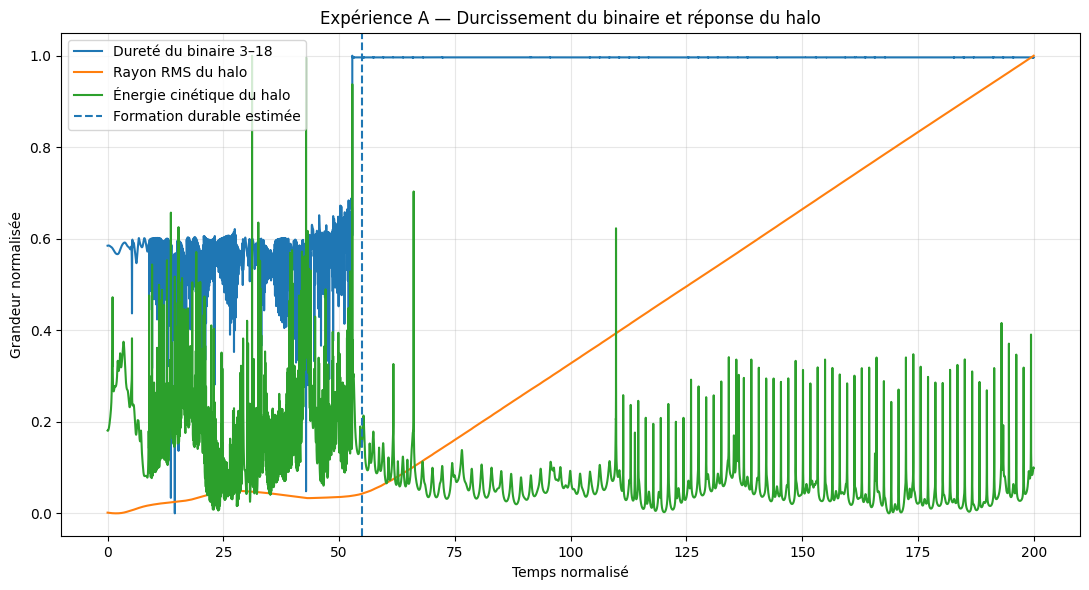

In [ ]:
# ============================================================
# Comparaison normalisée du binaire et du halo
# ============================================================

def minmax_normalize(
    values: np.ndarray,
    epsilon: float = 1e-15,
) -> np.ndarray:
    values = np.asarray(values, dtype=float)

    minimum = np.min(values)
    maximum = np.max(values)

    return (
        values - minimum
    ) / max(
        maximum - minimum,
        epsilon,
    )


binary_hardness_norm_A = minmax_normalize(
    binary_hardness_A
)

halo_radius_norm_A = minmax_normalize(
    rms_radius_halo_A
)

halo_kinetic_norm_A = minmax_normalize(
    kinetic_halo_A
)

plt.figure(figsize=(11, 6))

plt.plot(
    times_A_long,
    binary_hardness_norm_A,
    label="Dureté du binaire 3–18",
)

plt.plot(
    times_A_long,
    halo_radius_norm_A,
    label="Rayon RMS du halo",
)

plt.plot(
    times_A_long,
    halo_kinetic_norm_A,
    label="Énergie cinétique du halo",
)

if np.isfinite(binary_formation_time_A):
    plt.axvline(
        binary_formation_time_A,
        linestyle="--",
        label="Formation durable estimée",
    )

plt.xlabel("Temps normalisé")
plt.ylabel("Grandeur normalisée")
plt.title(
    "Expérience A — Durcissement du binaire et réponse du halo"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Énergie interne exacte de la paire dominante
# ============================================================

binary_internal_energy_A = binary_energy_A.copy()

binary_binding_energy_A = np.maximum(
    -binary_internal_energy_A,
    0.0,
)

print("Énergie interne du binaire")
print("--------------------------")
print(f"Initiale : {binary_internal_energy_A[0]:.12f}")
print(f"Finale   : {binary_internal_energy_A[-1]:.12f}")
print(
    "Variation : "
    f"{binary_internal_energy_A[-1] - binary_internal_energy_A[0]:.12f}"
)

Énergie interne du binaire
--------------------------
Initiale : 0.004981995855
Finale   : -0.146936903777
Variation : -0.151918899633


In [ ]:
# ============================================================
# Budget énergétique complémentaire
# ============================================================

energy_rest_A = (
    total_energy_A_long
    - binary_internal_energy_A
)

delta_binary_energy_A = (
    binary_internal_energy_A
    - binary_internal_energy_A[0]
)

delta_rest_energy_A = (
    energy_rest_A
    - energy_rest_A[0]
)

energy_budget_residual_A = (
    delta_binary_energy_A
    + delta_rest_energy_A
)

print("Budget énergétique binaire–reste")
print("--------------------------------")
print(
    f"Delta E binaire final : "
    f"{delta_binary_energy_A[-1]:.12f}"
)
print(
    f"Delta E reste final   : "
    f"{delta_rest_energy_A[-1]:.12f}"
)
print(
    "Résidu maximal        : "
    f"{np.max(np.abs(energy_budget_residual_A)):.12e}"
)

Budget énergétique binaire–reste
--------------------------------
Delta E binaire final : -0.151918899633
Delta E reste final   : 0.151918114010
Résidu maximal        : 7.856646703774e-07


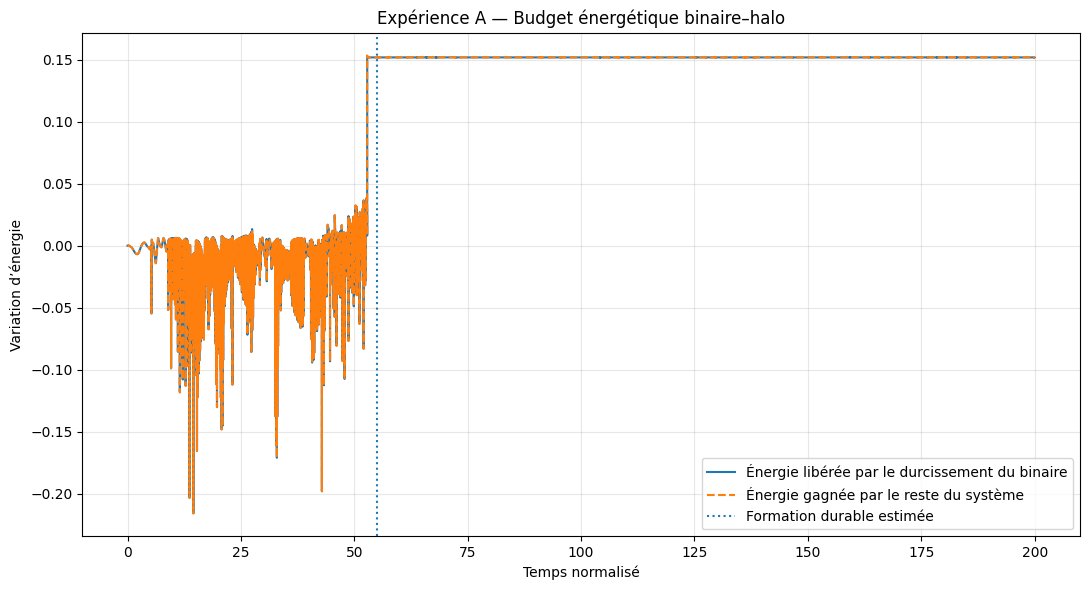

In [ ]:
# ============================================================
# Transfert énergétique cumulé
# ============================================================

energy_released_by_binary_A = (
    -delta_binary_energy_A
)

energy_gained_by_rest_A = (
    delta_rest_energy_A
)

plt.figure(figsize=(11, 6))

plt.plot(
    times_A_long,
    energy_released_by_binary_A,
    label="Énergie libérée par le durcissement du binaire",
)

plt.plot(
    times_A_long,
    energy_gained_by_rest_A,
    linestyle="--",
    label="Énergie gagnée par le reste du système",
)

plt.axvline(
    binary_formation_time_A,
    linestyle=":",
    label="Formation durable estimée",
)

plt.xlabel("Temps normalisé")
plt.ylabel("Variation d’énergie")
plt.title(
    "Expérience A — Budget énergétique binaire–halo"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Corrélation des taux de transfert
# ============================================================

binary_release_rate_A = -np.gradient(
    binary_internal_energy_A,
    times_A_long,
)

rest_gain_rate_A = np.gradient(
    energy_rest_A,
    times_A_long,
)

halo_growth_rate_A = np.gradient(
    rms_radius_halo_A,
    times_A_long,
)

transfer_mask_A = (
    times_A_long >= binary_formation_time_A
)

correlation_energy_rates_A = np.corrcoef(
    binary_release_rate_A[transfer_mask_A],
    rest_gain_rate_A[transfer_mask_A],
)[0, 1]

correlation_release_halo_growth_A = np.corrcoef(
    binary_release_rate_A[transfer_mask_A],
    halo_growth_rate_A[transfer_mask_A],
)[0, 1]

print("Corrélations des variations locales")
print("-----------------------------------")
print(
    "Libération binaire / gain du reste : "
    f"{correlation_energy_rates_A:.12f}"
)
print(
    "Libération binaire / croissance du halo : "
    f"{correlation_release_halo_growth_A:.12f}"
)

Corrélations des variations locales
-----------------------------------
Libération binaire / gain du reste : 0.999999999986
Libération binaire / croissance du halo : -0.000196438646
